In [ ]:
import pandas as pd
from google.colab import drive

# =============================================
# 0. Mount + Load Raw Dataset
# =============================================
drive.mount('/content/drive')

RAW_PATH  = "/content/drive/MyDrive/accepted_2007_to_2018Q4.csv"
CLEAN_PATH = "/content/drive/MyDrive/tapan1.0.csv"   # final output (overwritten)

print("Loading raw dataset...")
df = pd.read_csv(RAW_PATH, low_memory=False)
print("Initial shape:", df.shape)


# =============================================
# 1. DROP LEAKAGE + HIGH-MISSING + USELESS COLS
# =============================================
drop_cols = [

    # --- Leakage (NEVER ALLOW IN MODELING) ---
    "out_prncp","out_prncp_inv","total_pymnt_inv",
    "total_rec_prncp","total_rec_int","total_rec_late_fee",
    "last_pymnt_d",
    "last_pymnt_amnt","next_pymnt_d","last_credit_pull_d",
    "last_fico_range_low","last_fico_range_high",

    # --- Hardship / Settlement (99% missing) ---
    "hardship_flag","hardship_type","hardship_reason","hardship_status",
    "hardship_start_date","hardship_end_date","hardship_amount",
    "hardship_length","hardship_dpd","hardship_loan_status",
    "hardship_payoff_balance_amount","hardship_last_payment_amount",
    "payment_plan_start_date","orig_projected_additional_accrued_interest",
    "deferral_term","debt_settlement_flag_date","settlement_status",
    "settlement_date","settlement_amount","settlement_percentage",
    "settlement_term",

    # --- Text, URLs, junk ---
    "url","desc",

    # --- Identifiers (not useful, high-cardinality) ---
    "member_id",

    # --- Joint applicant (very sparse) ---
    "annual_inc_joint","dti_joint","verification_status_joint",
    "revol_bal_joint","sec_app_fico_range_low","sec_app_fico_range_high",
    "sec_app_earliest_cr_line","sec_app_inq_last_6mths",
    "sec_app_mort_acc","sec_app_open_acc","sec_app_revol_util",
    "sec_app_open_act_il","sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
print("After dropping leakage/missing/junk:", df.shape)


# =============================================
# 2. FILTER LOAN STATUS
# =============================================
good_status = ["Fully Paid"]

bad_status = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)"
]

drop_status = [
    "Current",
    "In Grace Period",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
]

# Drop rows with statuses we do NOT model
df = df[~df['loan_status'].isin(drop_status)]

# Remove NaN statuses
df = df[df['loan_status'].notna()]

# Keep only good vs bad
df = df[df['loan_status'].isin(good_status + bad_status)]
print("After filtering loan_status:", df.shape)


# =============================================
# 3. CREATE TARGET (0 = paid, 1 = default)
# =============================================
df["target"] = df["loan_status"].apply(lambda x: 1 if x in bad_status else 0)

# Drop the now-redundant status column
df = df.drop(columns=["loan_status"])
print("Target distribution:")
print(df["target"].value_counts(normalize=True) * 100)


# =============================================
# 4. SAVE (overwrite accepted_clean.csv)
# =============================================
df.to_csv(CLEAN_PATH, index=False)
print("\n✅ CLEANED + ENCODED dataset saved to:", CLEAN_PATH)
print("Final shape:", df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading raw dataset...
Initial shape: (2260701, 151)
After dropping leakage/missing/junk: (2260701, 99)
After filtering loan_status: (1371166, 99)
Target distribution:
target
0    78.528129
1    21.471871
Name: proportion, dtype: float64

✅ CLEANED + ENCODED dataset saved to: /content/drive/MyDrive/tapan1.0.csv
Final shape: (1371166, 99)


In [ ]:
import re
import pandas as pd
import numpy as np

IN_PATH = "/content/drive/MyDrive/tapan1.0.csv"
OUT_PATH = "/content/drive/MyDrive/tapan2.0.csv"

print("Loading:", IN_PATH)
df = pd.read_csv(IN_PATH, low_memory=False)
print("Initial shape:", df.shape)
# =========================================================
# FIX 1: Clean and convert 'term' → numeric months (36, 60)
# =========================================================
if 'term' in df.columns:
    if df['term'].dtype == 'O':
        print("Converting 'term' to integer...")
        df['term'] = (
            df['term']
            .astype(str)
            .str.lower()
            .str.replace('months', '', regex=False)
            .str.strip()
        )
        df['term'] = pd.to_numeric(df['term'], errors='coerce')

        # If any NaNs appear (extremely rare), impute majority term (36)
        df['term'] = df['term'].fillna(36).astype(int)
# =========================================================
# FIX 2: Replace messy emp_length strings with numeric scale
# =========================================================

emp_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

if 'emp_length' in df.columns:
    print("Encoding emp_length...")
    df['emp_length'] = df['emp_length'].astype(str).str.strip()
    df['emp_length'] = df['emp_length'].map(emp_map).fillna(0).astype(int)

    print(df['emp_length'].value_counts().sort_index())

# -------------------------------
# Drop identifier + simple drops
# -------------------------------
drop_simple = ["title", "zip_code", "debt_settlement_flag"]
for c in drop_simple:
    if c in df.columns:
        print("Dropping column:", c)
        df = df.drop(columns=[c])

# -------------------------------
# Create emp_category from emp_title, then drop emp_title
# -------------------------------
def map_emp_title(title):
    if pd.isna(title):
        return "Unknown"
    t = title.lower().strip()
    # Simple keyword mapping (extend as needed)
    if re.search(r"\b(teacher|instructor|tutor)\b", t): return "Education"
    if re.search(r"\b(nurse|rn|registered nurse|health|doctor|physician|therap)\b", t): return "Healthcare"
    if re.search(r"\b(engineer|developer|software|dev|programmer|it|data)\b", t): return "Engineering/IT"
    if re.search(r"\b(manager|director|vp|vice president|president|lead)\b", t): return "Management"
    if re.search(r"\b(driver|truck|delivery|operator|forklift)\b", t): return "Transportation"
    if re.search(r"\b(sales|salesman|account executive|account manager|marketing)\b", t): return "Sales/Marketing"
    if re.search(r"\b(owner|founder|ceo|co-founder|entrepreneur)\b", t): return "Business Owner"
    if re.search(r"\b(admin|assistant|office|clerical|receptionist|secretary)\b", t): return "Administrative"
    if re.search(r"\b(construction|electrician|plumber|carpenter|laborer|mechanic)\b", t): return "Trades/Construction"
    if re.search(r"\b(student)\b", t): return "Student"
    if re.search(r"\b(retired)\b", t): return "Retired"
    if re.search(r"\b(unemployed|looking)\b", t): return "Unemployed"
    if re.search(r"\b(bank|finance|accountant|financial|audit|analyst)\b", t): return "Finance"
    if re.search(r"\b(restaurant|chef|cook|barista|waiter|waitress|hospitality|hotel)\b", t): return "Hospitality"
    # fallback
    return "Other"

if "emp_title" in df.columns:
    print("Mapping emp_title -> emp_cat")
    df["emp_cat"] = df["emp_title"].astype(str).apply(map_emp_title)
    df = df.drop(columns=["emp_title"])

# -------------------------------
# Map addr_state -> census region & simple state tax flag
# -------------------------------
state_to_region = {
    # Northeast
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    # Midwest
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',
    # South
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South',
    'WV':'South','AL':'South','KY':'South','MS':'South','TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    # West
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West','AK':'West','CA':'West',
    'HI':'West','OR':'West','WA':'West'
}

# States with no broad-based individual income tax (subject to minor exceptions)
no_income_tax_states = set(['AK','FL','NV','SD','TX','WA','WY','NH','TN'])  # NH/TN treat as special cases historically

def map_region(state):
    if pd.isna(state): return "Unknown"
    return state_to_region.get(state, "Other")

def map_state_tax(state):
    if pd.isna(state): return "Unknown"
    s = state.upper()
    if s in no_income_tax_states:
        return "None"
    # Note: you can replace this with a more nuanced High/Low mapping externally.
    return "HasTax"

if "addr_state" in df.columns:
    print("Mapping addr_state -> zip_region & state_income_tax")
    df["zip_region"] = df["addr_state"].apply(map_region)
    df["state_income_tax"] = df["addr_state"].apply(map_state_tax)

# -------------------------------
# Drop raw zip_code if present (we already dropped earlier)
# -------------------------------

# -------------------------------
# Columns lists based on your plan
# -------------------------------

months_cols = [
    "mths_since_last_record",
    "mths_since_recent_bc_dlq",
    "mths_since_last_major_derog",
    "mths_since_recent_revol_delinq",
    "mths_since_last_delinq",
    "mths_since_recent_inq",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mths_since_recent_bc",
    "mo_sin_rcnt_tl",
    "mths_since_rcnt_il"
]

# Post-2013 extended-credit columns (master flag)
extended_cols = [
    "open_acc_6m","total_cu_tl","open_il_24m","open_il_12m","inq_fi",
    "open_rv_12m","open_rv_24m","open_act_il","inq_last_12m","max_bal_bc",
    "total_bal_il"
]

# utilization
util_cols = ["il_util", "all_util"]

# counts -> fill 0
count_cols = [
    "num_tl_120dpd_2m","num_bc_sats","num_sats","num_accts_ever_120_pd",
    "num_rev_tl_bal_gt_0","num_actv_rev_tl","num_il_tl","num_actv_bc_tl",
    "num_bc_tl","num_tl_op_past_12m","num_op_rev_tl","num_tl_90g_dpd_24m",
    "num_tl_30dpd"
]

# totals / balances to fill 0
total_zero_cols = [
    "total_bc_limit","total_bal_ex_mort","tot_cur_bal","tot_coll_amt",
    "total_il_high_credit_limit","tot_hi_cred_lim","total_rev_hi_lim",
    "acc_open_past_24mths","mort_acc","num_bc_sats","num_sats","num_rev_accts",
    "bc_util","percent_bc_gt_75","avg_cur_bal"
]

# small-missing -> drop rows
droprow_cols = [
    "dti","revol_util","collections_12_mths_ex_med","chargeoff_within_12_mths",
    "tax_liens","inq_last_6mths","pub_rec_bankruptcies"
]

# -------------------------------
# 1) Months-since vars: missing flag + max-impute (999)
# -------------------------------
for c in months_cols:
    if c in df.columns:
        flag = c + "_missing"
        print("Creating flag and imputing max for:", c)
        df[flag] = df[c].isna().astype(int)
        df[c] = df[c].fillna(999)

# -------------------------------
# 2) Extended credit -> Data Era flag + impute
# -------------------------------
# Create issue year
if "issue_d" in df.columns:
    # parse issue_d like 'Mar-2016'
    try:
        df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format="%b-%Y", errors='coerce')
    except Exception as e:
        df['issue_d_dt'] = pd.to_datetime(df['issue_d'], errors='coerce')

    df['issue_year'] = df['issue_d_dt'].dt.year
    # define post2013 flag
    df['post_2013_credit'] = (df['issue_year'] >= 2013).astype(int)
else:
    df['post_2013_credit'] = 0

# master extended-data available flag: True if any of extended_cols non-null
extended_present = []
for c in extended_cols:
    if c in df.columns:
        extended_present.append(df[c].notna())

if len(extended_present) > 0:
    df['extended_credit_data_present'] = np.vstack(extended_present).any(axis=0).astype(int)
else:
    df['extended_credit_data_present'] = 0

# Impute extended_cols: for both pre and post 2013 we will fillna(0)
# (pre-2013 everyone gets zeros; post-2013 missing -> nothing to report -> 0)
for c in extended_cols:
    if c in df.columns:
        print("Imputing extended credit col to 0:", c)
        df[c] = df[c].fillna(0)

# -------------------------------
# 3) Utilization: add missing flag + fill 0
# -------------------------------
for c in util_cols:
    if c in df.columns:
        flag = c + "_missing"
        print("Handling util col:", c)
        df[flag] = df[c].isna().astype(int)
        df[c] = df[c].fillna(0)

# -------------------------------
# 4) Counts: fill 0
# -------------------------------
for c in count_cols:
    if c in df.columns:
        print("Filling count col with 0:", c)
        df[c] = df[c].fillna(0)

# -------------------------------
# 5) totals / balances: fill 0
# -------------------------------
for c in total_zero_cols:
    if c in df.columns:
        print("Filling total/limit col with 0:", c)
        df[c] = df[c].fillna(0)

# -------------------------------
# 6) pct_tl_nvr_dlq -> fill 100 when NaN (innocent until proven guilty)
# -------------------------------
if "pct_tl_nvr_dlq" in df.columns:
    print("Filling pct_tl_nvr_dlq NaN with 100")
    df["pct_tl_nvr_dlq_missing"] = df["pct_tl_nvr_dlq"].isna().astype(int)
    df["pct_tl_nvr_dlq"] = df["pct_tl_nvr_dlq"].fillna(100)

# -------------------------------
# 7) bc_open_to_buy -> fill 0 + flag
# -------------------------------
if "bc_open_to_buy" in df.columns:
    print("Handling bc_open_to_buy")
    df["bc_open_to_buy_missing"] = df["bc_open_to_buy"].isna().astype(int)
    df["bc_open_to_buy"] = df["bc_open_to_buy"].fillna(0)

# -------------------------------
# 8) emp_length -> fillna 0
# -------------------------------
if "emp_length" in df.columns:
    print("Filling emp_length NaN -> 0")
    # convert textual values to numeric if present (like "10+ years")
    def parse_emp_len(x):
        if pd.isna(x): return np.nan
        s = str(x).strip()
        if s == "10+ years": return 10
        if "< 1" in s: return 0
        try:
            return int(re.search(r"(\d+)", s).group(1))
        except:
            return np.nan
    df["emp_length_num"] = df["emp_length"].apply(parse_emp_len)
    df["emp_length_num"] = df["emp_length_num"].fillna(0)

# -------------------------------
# 9) For tiny missingness columns -> drop rows (safe)
# -------------------------------
to_drop_rows = [c for c in droprow_cols if c in df.columns]
print("Dropping rows where any of these columns are NaN (tiny %):", to_drop_rows)
if len(to_drop_rows) > 0:
    before = df.shape[0]
    df = df.dropna(subset=to_drop_rows)
    after = df.shape[0]
    print(f"Dropped {before-after} rows; new shape {df.shape}")

# -------------------------------
# 10) Ensure revol_util and dti exist and are numeric
# -------------------------------
for c in ["revol_util","dti"]:
    if c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        except:
            pass
        # already dropped rows with NaN if in droprow_cols, but fill any remnant with median
        if df[c].isna().sum() > 0:
            df[c] = df[c].fillna(df[c].median())

# -------------------------------
# 11) Final sanity flags for key relationships
# -------------------------------
# If someone has total_bc_limit == 0 but bc_open_to_buy == 0, mark 'no_card'
if ("total_bc_limit" in df.columns) and ("bc_open_to_buy" in df.columns):
    df["no_card_flag"] = ((df["total_bc_limit"] == 0) & (df["bc_open_to_buy"] == 0)).astype(int)

# If extended_credit_data_present == 0 but post_2013_credit == 1, we mark it (rare)
if "extended_credit_data_present" in df.columns and "post_2013_credit" in df.columns:
    df["post2013_no_extended_data"] = ((df["post_2013_credit"]==1) & (df["extended_credit_data_present"]==0)).astype(int)

# -------------------------------
# 12) Reorder / cleanup / save
# -------------------------------
# Drop helper columns if you don't want to keep (issue_d_dt etc). Keep issue_year maybe.
if "issue_d_dt" in df.columns:
    df = df.drop(columns=["issue_d_dt"])
# if you prefer to drop original emp_length col and keep emp_length_num
if "emp_length" in df.columns:
    df = df.drop(columns=["emp_length"])

print("Final shape before save:", df.shape)
print("Saving to:", OUT_PATH)
df.to_csv(OUT_PATH, index=False)
print("Saved. Done.")


Loading: /content/drive/MyDrive/tapan1.0.csv
Initial shape: (1371166, 99)
Converting 'term' to integer...
Encoding emp_length...
emp_length
0     191337
1      90224
2     124103
3     109738
4      82225
5      85749
6      63854
7      60546
8      61621
9      51701
10    450068
Name: count, dtype: int64
Dropping column: title
Dropping column: zip_code
Dropping column: debt_settlement_flag
Mapping emp_title -> emp_cat
Mapping addr_state -> zip_region & state_income_tax
Creating flag and imputing max for: mths_since_last_record
Creating flag and imputing max for: mths_since_recent_bc_dlq
Creating flag and imputing max for: mths_since_last_major_derog
Creating flag and imputing max for: mths_since_recent_revol_delinq
Creating flag and imputing max for: mths_since_last_delinq
Creating flag and imputing max for: mths_since_recent_inq
Creating flag and imputing max for: mo_sin_old_il_acct
Creating flag and imputing max for: mo_sin_old_rev_tl_op
Creating flag and imputing max for: mo_sin_

In [ ]:
# =============================================================
#   FULL PIPELINE: CLEANING + FEATURE ENGINEERING +
#   CATEGORICAL NORMALIZATION (NO ONE-HOT, NO TE YET)
# =============================================================

import pandas as pd
import numpy as np

INPATH  = "/content/drive/MyDrive/tapan2.0.csv"
OUTPATH = "/content/drive/MyDrive/tapan3.0.csv"

print("Loading:", INPATH)
df = pd.read_csv(INPATH, low_memory=False)
print("Initial shape:", df.shape)

# ============================================================
# 1) FICO midpoint
# ============================================================
if "fico_range_low" in df.columns and "fico_range_high" in df.columns:
    print("Calculating FICO Score...")
    df["fico_score"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
    df = df.drop(columns=["fico_range_low", "fico_range_high"], errors="ignore")

# ============================================================
# 2) Subgrade Ordinal Encoding (A1=1 → G5=35)
# ============================================================
def subgrade_to_ordinal(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    if len(s) < 2:
        return np.nan
    letter = s[0]
    num = int(s[1])
    letter_idx = ord(letter) - ord('A')
    return letter_idx * 5 + num

if "sub_grade" in df.columns:
    print("Encoding sub_grade → ordinal...")
    df["sub_grade_ord"] = df["sub_grade"].apply(subgrade_to_ordinal).astype("Int64")


# ============================================================
# 3) Installment / Income ratio
# ============================================================
if {"installment","annual_inc"}.issubset(df.columns):
    print("Creating installment_to_income...")
    df["installment_to_income"] = df["installment"] / df["annual_inc"].replace(0, np.nan)
    df["installment_to_income"] = df["installment_to_income"].replace([np.inf,-np.inf], np.nan)

# ============================================================
# 4) Drop unwanted redundant columns
# ============================================================
drop_cols = [
    "policy_code","pymnt_plan","disbursement_method",
    "addr_state","funded_amnt","funded_amnt_inv"
]
print("Dropping redundant columns...")
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# ============================================================
# 5) Parse Dates → Extract Features → Drop datetime
# ============================================================
print("Processing dates...")

# Issue Date
if "issue_d" in df.columns:
    df["issue_d_dt"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
    df["issue_year"] = df["issue_d_dt"].dt.year
    df["issue_month"] = df["issue_d_dt"].dt.month
    df = df.drop(columns=["issue_d"], errors="ignore")

# Earliest credit line
if "earliest_cr_line" in df.columns:
    df["earliest_cr_line_dt"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
    df = df.drop(columns=["earliest_cr_line"], errors="ignore")

# Credit age
if "issue_d_dt" in df.columns and "earliest_cr_line_dt" in df.columns:
    df["credit_age_months"] = ((df["issue_d_dt"] - df["earliest_cr_line_dt"]).dt.days // 30)

# Drop datetimes
for col in ["issue_d_dt", "earliest_cr_line_dt"]:
    if col in df.columns:
        df = df.drop(columns=[col], errors="ignore")

# ============================================================
# 6) PROPER CATEGORICAL NORMALIZATION (NO ONE-HOT)
# ============================================================

# A) home_ownership → Ordinal
home_map = {
    "OWN": 2,
    "MORTGAGE": 1,
    "RENT": 0,
    "OTHER": -1,
    "NONE": -1
}
if "home_ownership" in df.columns:
    print("Encoding home_ownership → ordinal mapping")
    df["home_ownership"] = df["home_ownership"].astype(str).str.upper().map(home_map).fillna(-1).astype(int)

# B) verification_status → Ordinal
vs_map = {
    "Verified": 2,
    "Source Verified": 1,
    "Not Verified": 0
}
if "verification_status" in df.columns:
    print("Encoding verification_status → ordinal")
    #df["verification_status"] = df["verification_status"].replace(vs_map).fillna(0).astype(int)
    df["verification_status"] = (
    df["verification_status"]
    .str.lower()
    .map({"verified":2, "source verified":1, "not verified":0})
    .fillna(0)
).astype(int)
# C) purpose → leave as category (TE will apply later)
if "purpose" in df.columns:
    print("Setting purpose as categorical (for TE later)...")
    df["purpose"] = df["purpose"].astype(str)

# D) application_type → binary 0/1
if "application_type" in df.columns:
    print("Encoding application_type → 0/1")
    df["application_type"] = df["application_type"].apply(lambda x: 1 if "Joint" in str(x) else 0)

# E) emp_cat → category (TE later)
if "emp_cat" in df.columns:
    print("Marking emp_cat as categorical...")
    df["emp_cat"] = df["emp_cat"].astype(str)

# F) zip_region → categorical (for LightGBM category feature)
if "zip_region" in df.columns:
    print("Marking zip_region as category...")
    df["zip_region"] = df["zip_region"].astype(str)

# G) state_income_tax → binary ordinal
if "state_income_tax" in df.columns:
    tax_map = {"HasTax":1, "None":0}
    print("Encoding state_income_tax → 0/1")
    df["state_income_tax"] = df["state_income_tax"].replace(tax_map).fillna(1).astype(int)
# ============================================================
# OPTIONAL: Log1p Transform for Highly Skewed Numeric Columns
# ============================================================
log_cols = [
    "annual_inc", "revol_bal", "delinq_amnt",
    "loan_amnt", "tot_cur_bal", "avg_cur_bal", "tot_coll_amt"
]

print("Applying log1p transforms to selected numeric columns...")
for col in log_cols:
    if col in df.columns:
        # Ensure column is numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # log1p to handle zeros safely
        df[col] = np.log1p(df[col].fillna(0))

# ============================================================
# 7) Final cleanup
# ============================================================
df = df.replace([np.inf, -np.inf], np.nan)

print("Final shape:", df.shape)
df.to_csv(OUTPATH, index=False)
print("Saved →", OUTPATH)
print("Done.")


Loading: /content/drive/MyDrive/tapan2.0.csv
Initial shape: (1369177, 119)
Calculating FICO Score...
Encoding sub_grade → ordinal...
Creating installment_to_income...
Dropping redundant columns...
Processing dates...
Encoding home_ownership → ordinal mapping
Encoding verification_status → ordinal
Setting purpose as categorical (for TE later)...
Encoding application_type → 0/1
Marking emp_cat as categorical...
Marking zip_region as category...
Encoding state_income_tax → 0/1


/tmp/ipython-input-455475041.py:142: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["state_income_tax"] = df["state_income_tax"].replace(tax_map).fillna(1).astype(int)


Applying log1p transforms to selected numeric columns...
Final shape: (1369177, 114)
Saved → /content/drive/MyDrive/tapan3.0.csv
Done.


In [ ]:
# ==============================================================================
# 🏆 GRANDMASTER v3: Corrected Scaling + CatBoost Native (No Leakage)
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')
import os
import gc
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from catboost import CatBoostClassifier, Pool
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# ----------------------------- CONFIG ---------------------------------
INPUT_PATH = "/content/drive/MyDrive/tapan3.0.csv"
MODEL_DIR = "/content/drive/MyDrive/"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

UNIT_PROFIT = 1500
UNIT_LOSS   = -9000

USE_GPU_CATBOOST = True  # Fallback to CPU if unavailable

# ----------------------------- LOAD + BASE FE --------------------------
print(f"Loading {INPUT_PATH}...")
df = pd.read_csv(INPUT_PATH, low_memory=False)
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

print("Generating Nuclear Features...")
EPS = 1e-6
if "acc_open_past_24mths" in df.columns and "total_acc" in df.columns:
    df["recent_expansion_ratio"] = df["acc_open_past_24mths"] / (df["total_acc"] + EPS)
if {"installment","annual_inc"}.issubset(df.columns):
    revol = df["revol_bal"] if "revol_bal" in df.columns else 0
    df["debt_service_ratio"] = (df["installment"] + (revol * 0.03)) / ((df["annual_inc"] / 12.0) + EPS)
if {"bc_util","il_util"}.issubset(df.columns):
    df["utilization_gap"] = (df["bc_util"].fillna(0) - df["il_util"].fillna(0)).clip(-100, 100)

for c in ["recent_expansion_ratio","debt_service_ratio","utilization_gap"]:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype("float32")

# ============================================================
# 🚫 DROP LEAKAGE AFTER FEATURE CREATION (Before Train/Test Split)
# ============================================================

LEAKAGE_COLS = [
    "recoveries",
    "total_pymnt",
    "collection_recovery_fee",
]

ID_COLS = ["id"]

DROP_FOR_MODEL = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]

print("\nDropping leakage columns BEFORE splitting:", DROP_FOR_MODEL)

df = df.drop(columns=DROP_FOR_MODEL, errors="ignore")

# ----------------------------- SORT & SPLIT ----------------------------
print("Sorting & Splitting Data (temporal)...")
df = df.sort_values(["issue_year","issue_month"]).reset_index(drop=True)

train_df = df[df.issue_year < 2016].copy().reset_index(drop=True)
valid_df = df[df.issue_year == 2016].copy().reset_index(drop=True)
test_df  = df[df.issue_year > 2016].copy().reset_index(drop=True)
del df; gc.collect()

print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {test_df.shape}")

# ----------------------------- NN STACKER SETUP ------------------------
embed_cols = [c for c in ["purpose","emp_cat"] if c in train_df.columns]

# Rich numeric context for NN
candidate_numeric_nn = [
    "int_rate","fico_score","credit_age_months",
    "recent_expansion_ratio","debt_service_ratio","utilization_gap",
    "revol_util","dti","annual_inc","loan_amnt","installment",
    "installment_to_income","revol_bal","total_bal_ex_mort","total_bc_limit",
    "tot_cur_bal","tot_hi_cred_lim"
]
numeric_nn_cols = [c for c in candidate_numeric_nn if c in train_df.columns]
print("NN numeric features:", numeric_nn_cols)

# 1. Label Encoders for Embeddings
encoders = {}
for c in embed_cols:
    le = LabelEncoder()
    all_vals = list(train_df[c].astype(str)) + list(valid_df[c].astype(str)) + list(test_df[c].astype(str))
    le.fit(all_vals)
    encoders[c] = le

# 2. Scaler for Numerics (CRITICAL FIX)
print("Fitting StandardScaler for NN inputs...")
scaler = StandardScaler()
# Fit on TRAIN only to prevent leakage
scaler.fit(train_df[numeric_nn_cols].fillna(0))

def prep_nn_inputs(sub_df):
    inputs = []
    # Embeddings
    for c in embed_cols:
        arr = encoders[c].transform(sub_df[c].astype(str))
        inputs.append(arr)

    # Numerics
    if numeric_nn_cols:
        # Fill NA
        raw_numerics = sub_df[numeric_nn_cols].fillna(0)
        # Log Transform Heavy Tails
        for col in ["annual_inc","loan_amnt","revol_bal","total_bal_ex_mort","total_bc_limit"]:
            if col in raw_numerics.columns:
                raw_numerics[col] = np.log1p(raw_numerics[col])

        # SCALE (The Fix)
        scaled_numerics = scaler.transform(raw_numerics)
        inputs.append(scaled_numerics.astype("float32"))
    else:
        inputs.append(np.zeros((len(sub_df),1), dtype="float32"))

    return inputs

def build_nn():
    nn_inputs = []
    emb_layers = []

    # Embedding Layers
    for c in embed_cols:
        vocab = len(encoders[c].classes_) + 1
        dim = min(16, max(4, vocab // 8 + 1))
        inp = Input(shape=(1,), name=f"{c}_in")
        emb = Embedding(vocab, dim, name=f"{c}_emb")(inp)
        nn_inputs.append(inp)
        emb_layers.append(Flatten()(emb))

    # Numeric Input
    num_dim = len(numeric_nn_cols) if numeric_nn_cols else 1
    num_in = Input(shape=(num_dim,), name="num_in")
    nn_inputs.append(num_in)

    x = Concatenate()(emb_layers + [num_in])
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(nn_inputs, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
    return model

# ----------------------------- TEMPORAL OOF NN -------------------------
print("\n--- Generating Temporal OOF NN Risk Score ---")
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

oof_preds = np.zeros(len(train_df), dtype="float32")
seen_indices = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(train_df)):
    print(f"  Fold {fold+1}/{n_splits}...")
    X_tr = prep_nn_inputs(train_df.iloc[tr_idx])
    y_tr = train_df["target"].iloc[tr_idx].values
    X_val = prep_nn_inputs(train_df.iloc[val_idx])

    nn = build_nn()
    nn.fit(X_tr, y_tr, epochs=6, batch_size=2048, verbose=0)
    preds = nn.predict(X_val, batch_size=4096).flatten().astype("float32")
    oof_preds[val_idx] = preds
    seen_indices.extend(val_idx)

# Fill initial chunk with mean
unseen_mask = np.ones(len(train_df), dtype=bool)
unseen_mask[seen_indices] = False
if unseen_mask.any():
    mean_risk = oof_preds[~unseen_mask].mean()
    oof_preds[unseen_mask] = mean_risk

train_df["nn_risk_score"] = oof_preds
print("  -> OOF nn_risk_score created for train.")

# ----------------------------- FINAL NN FOR VAL/TEST -------------------
print("Training Final NN on ALL train...")
X_full = prep_nn_inputs(train_df)
y_full = train_df["target"].values
final_nn = build_nn()
final_nn.fit(X_full, y_full, epochs=8, batch_size=2048, verbose=0)

valid_df["nn_risk_score"] = final_nn.predict(prep_nn_inputs(valid_df), batch_size=4096).flatten()
test_df["nn_risk_score"]  = final_nn.predict(prep_nn_inputs(test_df),  batch_size=4096).flatten()

# ----------------------------- CATBOOST SETUP --------------------------
print("Preparing CatBoost features...")

# REMOVED: External Target Encoding (Redundant & Leaky)
# CatBoost handles these natively.

# Combine Feature Lists
# numeric cols (includes nn_risk_score + nukes)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Native Categoricals for CatBoost
# We include sub_grade/grade strings here so CatBoost uses its internal Ordered TS encoding
cat_feats = [
    "grade","sub_grade","purpose","emp_cat","home_ownership",
    "initial_list_status","zip_region"
]
cat_feats = [c for c in cat_feats if c in train_df.columns]

exclude = ["target","issue_year","issue_month","loan_status"]
features = [c for c in numeric_cols + cat_feats if c not in exclude]
features = list(dict.fromkeys(features))  # dedupe

print("  #features:", len(features))
print("  Categorical features:", cat_feats)

# Fill NaNs for Cats (CatBoost requires strings)
for c in cat_feats:
    train_df[c] = train_df[c].fillna("Missing").astype(str)
    valid_df[c] = valid_df[c].fillna("Missing").astype(str)
    test_df[c]  = test_df[c].fillna("Missing").astype(str)

# Imbalance Weight
n_pos = train_df["target"].sum()
n_neg = len(train_df) - n_pos
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight =", scale_pos_weight)

train_pool = Pool(train_df[features], train_df["target"], cat_features=cat_feats)
valid_pool = Pool(valid_df[features], valid_df["target"], cat_features=cat_feats)

# ----------------------------- TRAIN CATBOOST --------------------------
print("Training CatBoost...")
task_type = "GPU" if USE_GPU_CATBOOST else "CPU"

params = dict(
    iterations=4000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=RANDOM_SEED,
    verbose=200,
    early_stopping_rounds=200,
    task_type=task_type
)

try:
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool)
except Exception as e:
    print("CatBoost GPU failed, falling back to CPU:", e)
    params["task_type"] = "CPU"
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool)

# ----------------------------- CALIBRATION & METRICS -------------------
print("Calibrating with IsotonicRegression on VALID...")
iso = IsotonicRegression(out_of_bounds="clip")
valid_raw = model.predict_proba(valid_pool)[:,1]
iso.fit(valid_raw, valid_df["target"].values)

test_raw = model.predict_proba(test_df[features])[:,1]
test_cal = iso.predict(test_raw)

auc_test = roc_auc_score(test_df["target"], test_cal)
print(f"\n🔥 Final Test AUC (calibrated): {auc_test:.4f}")

# Quick Profit Check
best_p, best_t = -np.inf, 0.5
y_test = test_df["target"].values
for t in np.linspace(0.01, 0.9, 100):
    approve = test_cal < t
    tn = np.sum((approve == 1) & (y_test == 0))
    fn = np.sum((approve == 1) & (y_test == 1))
    profit = tn * UNIT_PROFIT + fn * UNIT_LOSS
    if profit > best_p:
        best_p, best_t = profit, t

print(f"Max Profit (Global cutoff {best_t:.3f}): ${best_p:,.0f}")

# ----------------------------- SAVE ARTIFACTS --------------------------
print("\nSaving artifacts...")
model.save_model(os.path.join(MODEL_DIR, "final_catboost2.0.cbm"))
with open(os.path.join(MODEL_DIR, "isotonic2.0.pkl"), "wb") as f:
    pickle.dump(iso, f)

# Save Stacking Artifacts (NN + Encoders + Scaler)
final_nn.save(os.path.join(MODEL_DIR, "final_nn_model2.0.keras"))
with open(os.path.join(MODEL_DIR, "embedding_encoders2.0.pkl"), "wb") as f:
    pickle.dump(encoders, f)
with open(os.path.join(MODEL_DIR, "nn_scaler2.0.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("✅ All artifacts saved. System Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading /content/drive/MyDrive/tapan3.0.csv...
Generating Nuclear Features...

Dropping leakage columns BEFORE splitting: ['recoveries', 'total_pymnt', 'collection_recovery_fee', 'id']
Sorting & Splitting Data (temporal)...
Train: (827509, 113), Valid: (298322, 113), Test: (243346, 113)
NN numeric features: ['int_rate', 'fico_score', 'credit_age_months', 'recent_expansion_ratio', 'debt_service_ratio', 'utilization_gap', 'revol_util', 'dti', 'annual_inc', 'loan_amnt', 'installment', 'installment_to_income', 'revol_bal', 'total_bal_ex_mort', 'total_bc_limit', 'tot_cur_bal', 'tot_hi_cred_lim']
Fitting StandardScaler for NN inputs...

--- Generating Temporal OOF NN Risk Score ---
  Fold 1/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
  Fold 2/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
  Fold 3/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
  Fold 4/5...
34/34 ━━━━

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6914416	best: 0.6914416 (0)	total: 110ms	remaining: 7m 20s
200:	test: 0.7164178	best: 0.7164178 (200)	total: 19.9s	remaining: 6m 15s
400:	test: 0.7200975	best: 0.7200975 (400)	total: 37.9s	remaining: 5m 39s
600:	test: 0.7221942	best: 0.7221942 (600)	total: 56s	remaining: 5m 16s
800:	test: 0.7234437	best: 0.7234437 (800)	total: 1m 14s	remaining: 4m 58s
1000:	test: 0.7242444	best: 0.7242444 (1000)	total: 1m 32s	remaining: 4m 37s
1200:	test: 0.7247924	best: 0.7248031 (1195)	total: 1m 50s	remaining: 4m 17s
1400:	test: 0.7251966	best: 0.7251966 (1400)	total: 2m 9s	remaining: 3m 59s
1600:	test: 0.7255387	best: 0.7255412 (1599)	total: 2m 26s	remaining: 3m 39s
1800:	test: 0.7256722	best: 0.7256947 (1796)	total: 2m 45s	remaining: 3m 22s
2000:	test: 0.7257981	best: 0.7257995 (1997)	total: 3m 3s	remaining: 3m 3s
2200:	test: 0.7258973	best: 0.7258981 (2199)	total: 3m 21s	remaining: 2m 44s
2400:	test: 0.7259451	best: 0.7259488 (2357)	total: 3m 40s	remaining: 2m 26s
2600:	test: 0.7260230	


--- Feature Importance (CatBoost) ---


,feature,importance
98,sub_grade_ord,10.656283
1,term,10.188037
104,nn_risk_score,4.579908
7,dti,3.715662
2,int_rate,3.567995
5,annual_inc,3.169678
99,installment_to_income,2.918999
97,fico_score,2.634190
101,recent_expansion_ratio,2.555640
105,grade,2.165921


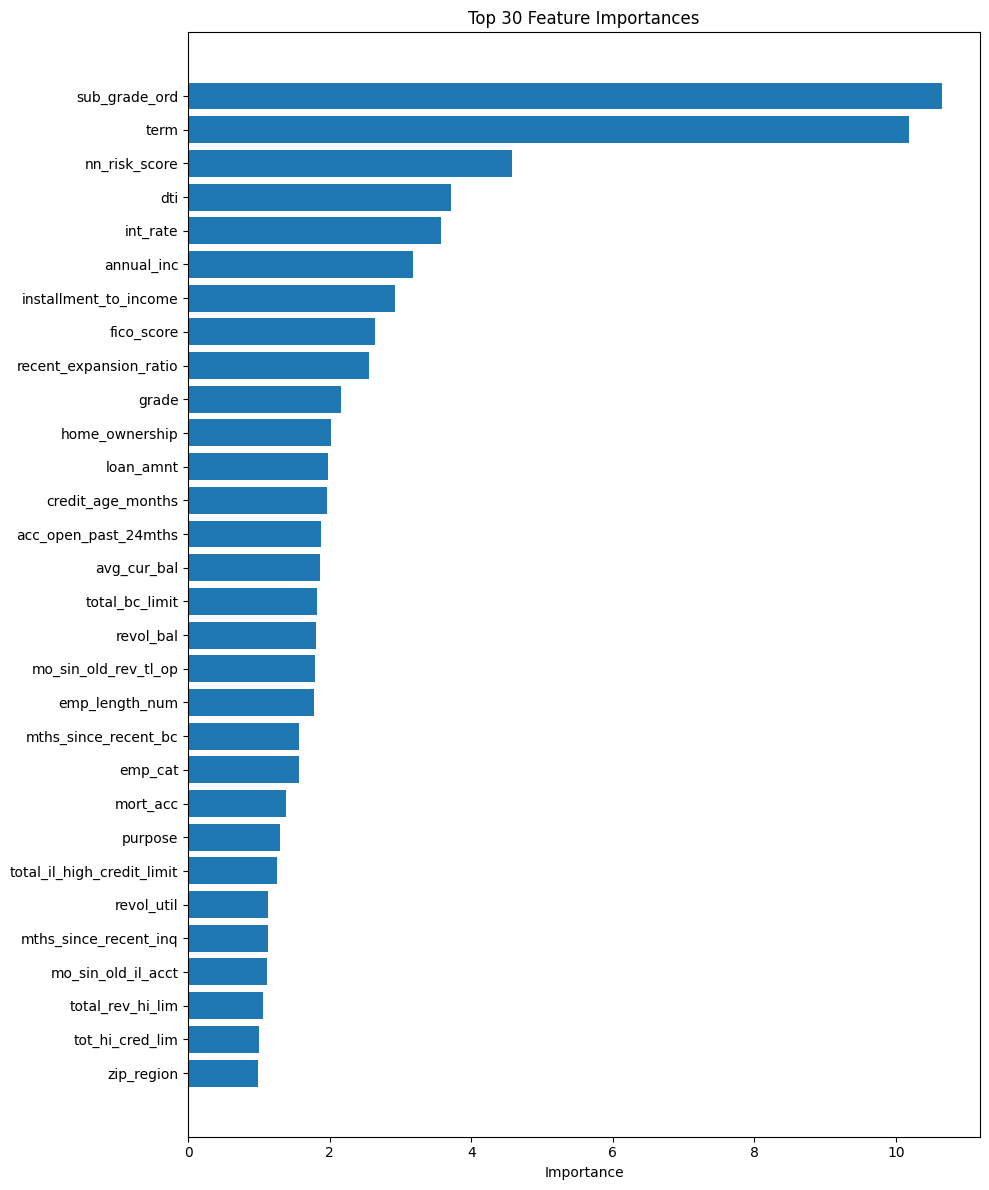

In [ ]:
# =============================
# 🔍 CATBOOST FEATURE IMPORTANCE
# =============================
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- Feature Importance (CatBoost) ---")
importance = model.get_feature_importance(train_pool)
fi_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values("importance", ascending=False)

display(fi_df.head(30))

# Optional: Plot
plt.figure(figsize=(10, 12))
plt.barh(fi_df["feature"].head(30)[::-1], fi_df["importance"].head(30)[::-1])
plt.title("Top 30 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# 🏛️ TWO-STAGE LGD MODELING (The "Hurdle" Approach) - Corrected
# ==============================================================================
import os
import pickle
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import roc_auc_score, r2_score, mean_absolute_error
from google.colab import drive
drive.mount('/content/drive')
# 1. SETUP & PATHS
df=pd.read_csv('/content/drive/MyDrive/tapan3.0.csv')
MODEL_DIR = "/content/drive/MyDrive"
os.makedirs(MODEL_DIR, exist_ok=True)
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

print("Generating Nuclear Features...")
EPS = 1e-6
if "acc_open_past_24mths" in df.columns and "total_acc" in df.columns:
    df["recent_expansion_ratio"] = df["acc_open_past_24mths"] / (df["total_acc"] + EPS)
if {"installment","annual_inc"}.issubset(df.columns):
    revol = df["revol_bal"] if "revol_bal" in df.columns else 0
    df["debt_service_ratio"] = (df["installment"] + (revol * 0.03)) / ((df["annual_inc"] / 12.0) + EPS)
if {"bc_util","il_util"}.issubset(df.columns):
    df["utilization_gap"] = (df["bc_util"].fillna(0) - df["il_util"].fillna(0)).clip(-100, 100)

for c in ["recent_expansion_ratio","debt_service_ratio","utilization_gap"]:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype("float32")

# ------------------------------------------------------------------------------
# STEP 0: FIX THE DATA (Inverse Log Transform)
# ------------------------------------------------------------------------------
# The previous steps likely log-transformed loan_amnt.
# We need RAW dollars to calculate Recovery Rate (Total_Pymnt / Loan_Amnt).
# If loan_amnt is ~9.5 (log), Total_Pymnt ($5000) / 9.5 = 50000% Recovery (Wrong).

print("Restoring raw loan_amnt from log scale...")

def restore_raw_loan_amnt(df):
    # Check if loan_amnt looks log-transformed (e.g., values < 20)
    # A $1,000 loan is ~6.9 in log. A $40,000 loan is ~10.6.
    # If max value is small, it's definitely logged.
    if df['loan_amnt'].max() < 50:
        # Inverse: exp(x) - 1 (assuming log1p was used)
        df['loan_amnt'] = np.expm1(df['loan_amnt'])
    return df
# ----------------------------- SORT & SPLIT ----------------------------
df = df.sort_values(["issue_year","issue_month"]).reset_index(drop=True)
train_df = df[df.issue_year < 2016].copy().reset_index(drop=True)
valid_df = df[df.issue_year == 2016].copy().reset_index(drop=True)
test_df  = df[df.issue_year > 2016].copy().reset_index(drop=True)

print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {test_df.shape}")

train_df = restore_raw_loan_amnt(train_df)
valid_df = restore_raw_loan_amnt(valid_df)
test_df  = restore_raw_loan_amnt(test_df)

print(f"Sample Loan Amount (Train): ${train_df['loan_amnt'].iloc[0]:,.2f}")

# ------------------------------------------------------------------------------
# STEP 1: FILTER DEFAULTS
# ------------------------------------------------------------------------------
# LGD models are ONLY trained on loans that have actually Defaulted/Charged Off.
def filter_defaults(df):
    # Filter for Target=1 (Defaulted)
    mask = df['target'] == 1
    return df[mask].copy()

print("Filtering for Defaulted Loans...")
lgd_train = filter_defaults(train_df)
lgd_valid = filter_defaults(valid_df)
lgd_test  = filter_defaults(test_df)

print(f"  Train Defaults: {len(lgd_train)}")
print(f"  Valid Defaults: {len(lgd_valid)}")

# ------------------------------------------------------------------------------
# STEP 2: CREATE TARGETS
# ------------------------------------------------------------------------------
def create_lgd_targets(df):
    # Safety: Ensure total_pymnt is present
    if 'total_pymnt' not in df.columns:
        raise ValueError("CRITICAL: 'total_pymnt' missing. Cannot calc LGD.")

    # Recovery Rate = Total Payment / Loan Amount
    # Clip at 1.0 (Recoveries > 100% are usually accounting weirdness/fees)
    rr = (df['recoveries'] / df['loan_amnt']).clip(0, 1)

    # Binary Target: Did we get anything meaningful back? (> 2% threshold)
    # 0.02 filters out noise (e.g. borrower paid $10 once then ghosted).
    has_recovery = (rr > 0.02).astype(int)

    return rr, has_recovery

# Apply to filtered dataframes
lgd_train['rr'], lgd_train['has_recovery'] = create_lgd_targets(lgd_train)
lgd_valid['rr'], lgd_valid['has_recovery'] = create_lgd_targets(lgd_valid)
lgd_test['rr'],  lgd_test['has_recovery']  = create_lgd_targets(lgd_test)

print(f"  Recovery Rate (Train Avg): {lgd_train['rr'].mean():.4f}")
print(f"  % with meaningful recovery: {lgd_train['has_recovery'].mean():.2%}")

# ------------------------------------------------------------------------------
# STEP 3: FEATURE ENGINEERING (Re-Creation)
# ------------------------------------------------------------------------------
# We need to define features again because the 'leakage' definition for LGD
# is different from PD (e.g. 'collection_recovery_fee' is leakage here too).

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = [
    "grade","sub_grade","purpose","emp_cat","home_ownership",
    "initial_list_status","zip_region"
]
# Ensure cats exist in the current DF
cat_feats = [c for c in cat_feats if c in lgd_train.columns]

# Exclude leakage & targets
leakage = [
    'target', 'rr', 'has_recovery', 'total_pymnt', 'recoveries',
    'collection_recovery_fee', 'loan_status', 'issue_year', 'issue_month',
    'total_rec_prncp', 'total_rec_int', 'last_pymnt_amnt'
]

features = [c for c in numeric_cols + cat_feats if c not in leakage]
features = list(dict.fromkeys(features)) # Deduplicate

# Fill Categorical NaNs for CatBoost
for c in cat_feats:
    lgd_train[c] = lgd_train[c].fillna("Missing").astype(str)
    lgd_valid[c] = lgd_valid[c].fillna("Missing").astype(str)
    lgd_test[c]  = lgd_test[c].fillna("Missing").astype(str)

print(f"Training LGD Models on {len(features)} features...")

# ------------------------------------------------------------------------------
# STAGE 1: CURE MODEL (Classifier)
# "Will we recover anything?" (Binary)
# ------------------------------------------------------------------------------
print("\nTraining Stage 1: Cure Probability Model...")

pool_cure_train = Pool(lgd_train[features], lgd_train['has_recovery'], cat_features=cat_feats)
pool_cure_valid = Pool(lgd_valid[features], lgd_valid['has_recovery'], cat_features=cat_feats)

cure_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
    allow_writing_files=False,
    task_type="CPU" # Use "GPU" if available and data is large
)

cure_model.fit(pool_cure_train, eval_set=pool_cure_valid)

# ------------------------------------------------------------------------------
# STAGE 2: SEVERITY MODEL (Regressor)
# "Given recovery, how much?" (Continuous)
# IMPORTANT: Train ONLY on rows where has_recovery == 1 (The "Cured" subset)
# ------------------------------------------------------------------------------
print("\nTraining Stage 2: Recovery Severity Model...")

# Filter for the "Yes" cases
mask_train = lgd_train['has_recovery'] == 1
mask_valid = lgd_valid['has_recovery'] == 1

X_sev_train = lgd_train.loc[mask_train, features]
y_sev_train = lgd_train.loc[mask_train, 'rr']

X_sev_valid = lgd_valid.loc[mask_valid, features]
y_sev_valid = lgd_valid.loc[mask_valid, 'rr']

pool_sev_train = Pool(X_sev_train, y_sev_train, cat_features=cat_feats)
pool_sev_valid = Pool(X_sev_valid, y_sev_valid, cat_features=cat_feats)

severity_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
    allow_writing_files=False,
    task_type="CPU"
)

severity_model.fit(pool_sev_train, eval_set=pool_sev_valid)

# ------------------------------------------------------------------------------
# COMBINE & EVALUATE
# ------------------------------------------------------------------------------
print("\nEvaluating Two-Stage LGD on Test Set (Defaulted Loans)...")

# 1. Predict P(Cure) - Probability of getting >2% back
p_cure = cure_model.predict_proba(lgd_test[features])[:, 1]

# 2. Predict Severity Rate - If we get money back, how much?
pred_sev = severity_model.predict(lgd_test[features])
pred_sev = np.clip(pred_sev, 0, 1) # Bound to 0-100%

# 3. Expected Recovery = P(Cure) * Severity
# Logic: If 50% chance of cure, and cure usually pays 40%, Expected = 20%
pred_rr = p_cure * pred_sev

# 4. Metrics
mae = mean_absolute_error(lgd_test['rr'], pred_rr)
r2 = r2_score(lgd_test['rr'], pred_rr)

print(f"LGD Model MAE: {mae:.4f} (Avg error in recovery rate)")
print(f"LGD Model R2:  {r2:.4f}")

# Example Output
print("\nExample Predictions:")
example = pd.DataFrame({
    'Loan_ID': lgd_test['id'].values[:5] if 'id' in lgd_test.columns else range(5),
    'Actual_RR': lgd_test['rr'].values[:5],
    'Pred_RR': pred_rr[:5],
    'P(Cure)': p_cure[:5],
    'Severity': pred_sev[:5]
})
print(example)

# ------------------------------------------------------------------------------
# SAVE
# ------------------------------------------------------------------------------
print("\nSaving LGD Artifacts...")
cure_model.save_model(os.path.join(MODEL_DIR, "lgd_cure_model.cbm"))
severity_model.save_model(os.path.join(MODEL_DIR, "lgd_severity_model.cbm"))
print("✅ Two-Stage LGD Models Saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generating Nuclear Features...
Restoring raw loan_amnt from log scale...
Train: (827509, 117), Valid: (298322, 117), Test: (243346, 117)
Sample Loan Amount (Train): $9,000.00
Filtering for Defaulted Loans...
  Train Defaults: 154136
  Valid Defaults: 73651
  Recovery Rate (Train Avg): 0.0780
  % with meaningful recovery: 67.21%
Training LGD Models on 111 features...

Training Stage 1: Cure Probability Model...
0:	test: 0.5504101	best: 0.5504101 (0)	total: 430ms	remaining: 7m 9s
100:	test: 0.5796558	best: 0.5797116 (99)	total: 39.4s	remaining: 5m 50s
200:	test: 0.5860751	best: 0.5861545 (197)	total: 1m 19s	remaining: 5m 16s
300:	test: 0.5880350	best: 0.5880350 (300)	total: 1m 59s	remaining: 4m 38s
400:	test: 0.5901425	best: 0.5901425 (400)	total: 2m 59s	remaining: 4m 27s
500:	test: 0.5908812	best: 0.5909003 (498)	total: 3m 46s	remaining: 3m 45s
Stopped by over

**CHECK FOR PRUNABLE FEATURES**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Train: (827509, 113), Valid: (298322, 113), Test: (243346, 113)
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Total features (model order): 111
Categorical features: ['home_ownership', 'grade', 'sub_grade', 'purpose', 'emp_cat', 'initial_list_status', 'zip_region']
Computing CatBoost feature importance...

Top 10 features by importance:
                    feature  importance
1                      term   10.387121
98            sub_grade_ord   10.194611
104           nn_risk_score    4.075462
7                       dti    3.748463
2                  int_rate    3.620568
5                annual_inc    3.190930
99    installment_to_income    2.938774
97               fico_score    2.648431
101  recent_expansion_ratio    2.586103
105                   grade    2.1789

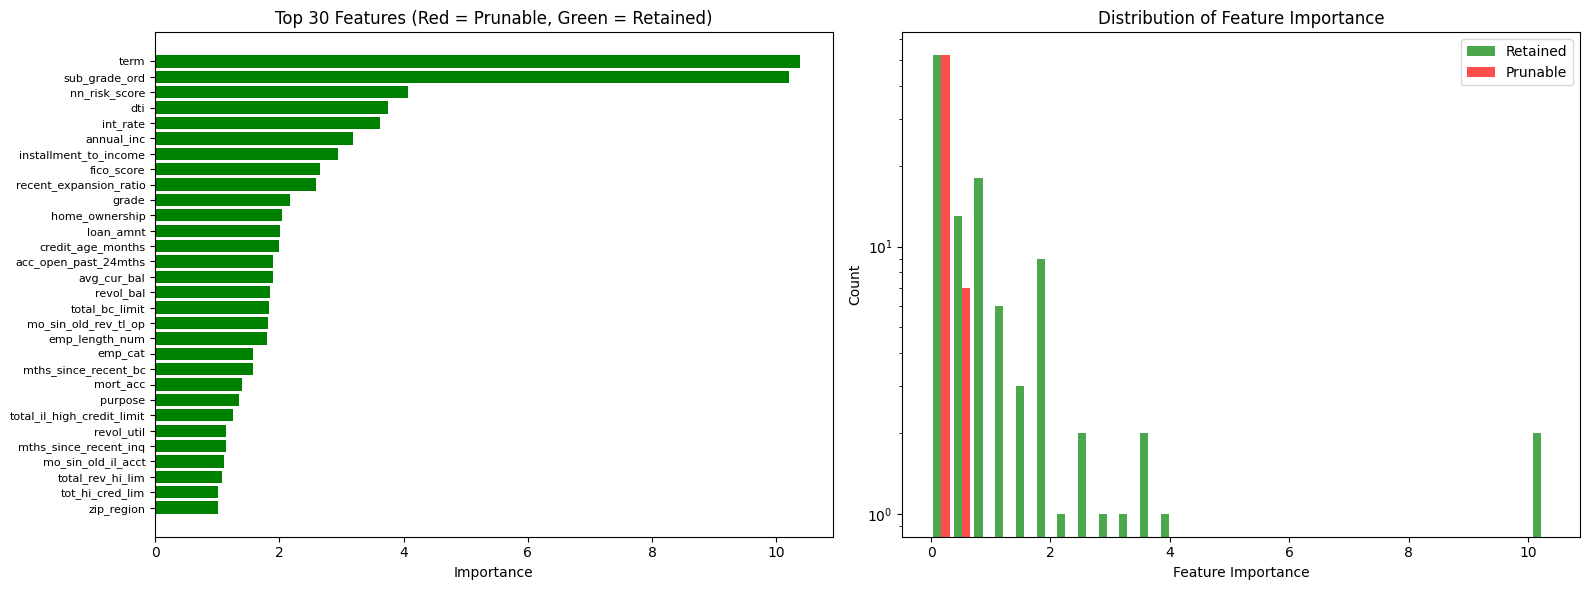


ANALYSIS COMPLETE


In [ ]:
# ==============================================================================
# 🔹 FULL PIPELINE: Dataset Load → Nuclear Features → NN Risk → CatBoost Pools
# ==============================================================================
!pip install catboost
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import pickle
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ----------------------------- CONFIG ---------------------------------
INPUT_PATH = "/content/drive/MyDrive/tapan3.0.csv"
MODEL_PATH = "/content/drive/MyDrive/final_catboost2.0.cbm"
NN_MODEL_PATH = "/content/drive/MyDrive/final_nn_model2.0.keras"
ENCODERS_PATH = "/content/drive/MyDrive/embedding_encoders2.0.pkl"
SCALER_PATH = "/content/drive/MyDrive/nn_scaler2.0.pkl"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ----------------------------- LOAD DATA ---------------------------------
print("Loading dataset...")
df = pd.read_csv(INPUT_PATH, low_memory=False)
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# ----------------------------- NUCLEAR FEATURES --------------------------
EPS = 1e-6
if {"acc_open_past_24mths","total_acc"}.issubset(df.columns):
    df["recent_expansion_ratio"] = df["acc_open_past_24mths"] / (df["total_acc"] + EPS)

if {"installment","annual_inc"}.issubset(df.columns):
    revol = df["revol_bal"] if "revol_bal" in df.columns else 0
    df["debt_service_ratio"] = (df["installment"] + (revol * 0.03)) / ((df["annual_inc"]/12.0) + EPS)

if {"bc_util","il_util"}.issubset(df.columns):
    df["utilization_gap"] = (df["bc_util"].fillna(0) - df["il_util"].fillna(0)).clip(-100,100)

for c in ["recent_expansion_ratio","debt_service_ratio","utilization_gap"]:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype("float32")

# ----------------------------- DROP LEAKAGE/ID ---------------------------
LEAKAGE_COLS = ["recoveries","total_pymnt","collection_recovery_fee"]
ID_COLS = ["id"]
df = df.drop(columns=[c for c in LEAKAGE_COLS+ID_COLS if c in df.columns], errors="ignore")

# ----------------------------- TEMPORAL SPLIT ----------------------------
df = df.sort_values(["issue_year","issue_month"]).reset_index(drop=True)
train_df = df[df.issue_year < 2016].copy().reset_index(drop=True)
valid_df = df[df.issue_year == 2016].copy().reset_index(drop=True)
test_df  = df[df.issue_year > 2016].copy().reset_index(drop=True)
del df; gc.collect()

print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {test_df.shape}")

# ----------------------------- LOAD NN STACKER ---------------------------
from tensorflow.keras.models import load_model
final_nn = load_model(NN_MODEL_PATH)

with open(ENCODERS_PATH,"rb") as f:
    encoders = pickle.load(f)
with open(SCALER_PATH,"rb") as f:
    scaler = pickle.load(f)

embed_cols = list(encoders.keys())

# Define numeric columns used by the NN
numeric_nn_cols = [
    "int_rate","fico_score","credit_age_months",
    "recent_expansion_ratio","debt_service_ratio","utilization_gap",
    "revol_util","dti","annual_inc","loan_amnt","installment",
    "installment_to_income","revol_bal","total_bal_ex_mort","total_bc_limit",
    "tot_cur_bal","tot_hi_cred_lim"
]
numeric_nn_cols = [c for c in numeric_nn_cols if c in train_df.columns]

def prep_nn_inputs(sub_df):
    inputs = []
    for c in embed_cols:
        arr = encoders[c].transform(sub_df[c].astype(str))
        inputs.append(arr)
    if numeric_nn_cols:
        raw_numerics = sub_df[numeric_nn_cols].fillna(0).copy()
        for col in ["annual_inc","loan_amnt","revol_bal","total_bal_ex_mort","total_bc_limit"]:
            if col in raw_numerics.columns:
                raw_numerics[col] = np.log1p(raw_numerics[col])
        scaled_numerics = scaler.transform(raw_numerics)
        inputs.append(scaled_numerics.astype("float32"))
    else:
        inputs.append(np.zeros((len(sub_df),1),dtype="float32"))
    return inputs

# ----------------------------- GENERATE NN RISK SCORE --------------------
for df_ in [train_df, valid_df, test_df]:
    if "nn_risk_score" not in df_.columns:
        df_["nn_risk_score"] = final_nn.predict(prep_nn_inputs(df_), batch_size=4096).flatten()

# ----------------------------- PREPARE CATBOOST FEATURES -----------------
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ["target","issue_year","issue_month"]
numeric_features = [c for c in numeric_features if c not in exclude]

# Categorical features (as in the model)
cat_feats_model = ['home_ownership','grade','sub_grade','purpose','emp_cat','initial_list_status','zip_region']
cat_feats_model = [c for c in cat_feats_model if c in train_df.columns]

# Fill missing for CatBoost
for c in cat_feats_model:
    for df_ in [train_df, valid_df, test_df]:
        df_[c] = df_[c].fillna("Missing").astype(str)

# Final feature list in **model order**
features = numeric_features + cat_feats_model
features = list(dict.fromkeys(features))  # dedupe just in case
print(f"Total features (model order): {len(features)}")
print("Categorical features:", cat_feats_model)

# ----------------------------- CREATE CATBOOST POOLS -------------------
train_pool = Pool(train_df[features], train_df["target"], cat_features=cat_feats_model)
valid_pool = Pool(valid_df[features], valid_df["target"], cat_features=cat_feats_model)
test_pool  = Pool(test_df[features],  test_df["target"],  cat_features=cat_feats_model)

# ----------------------------- LOAD CATBOOST MODEL --------------------
model = CatBoostClassifier()
model.load_model(MODEL_PATH)

# ----------------------------- FEATURE IMPORTANCE ----------------------
print("Computing CatBoost feature importance...")
importances = model.get_feature_importance(train_pool, type='FeatureImportance')
feat_imp_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 features by importance:")
print(feat_imp_df.head(10))
# ==============================================================================
# 🔹 FEATURE PRUNING ANALYSIS: Identify removable features without performance loss
# ==============================================================================

from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# ----------------------------- BASELINE PERFORMANCE --------------------------
print("=" * 80)
print("BASELINE MODEL PERFORMANCE")
print("=" * 80)

# Get baseline predictions
train_preds = model.predict_proba(train_pool)[:, 1]
valid_preds = model.predict_proba(valid_pool)[:, 1]
test_preds = model.predict_proba(test_pool)[:, 1]

# Calculate baseline metrics
baseline_train_auc = roc_auc_score(train_df["target"], train_preds)
baseline_valid_auc = roc_auc_score(valid_df["target"], valid_preds)
baseline_test_auc = roc_auc_score(test_df["target"], test_preds)

print(f"Train AUC: {baseline_train_auc:.6f}")
print(f"Valid AUC: {baseline_valid_auc:.6f}")
print(f"Test AUC:  {baseline_test_auc:.6f}")

# ----------------------------- IDENTIFY LOW IMPORTANCE FEATURES --------------
print("\n" + "=" * 80)
print("LOW IMPORTANCE FEATURES ANALYSIS")
print("=" * 80)

# Define thresholds for low importance
IMPORTANCE_THRESHOLD = 0.1  # Features below this are candidates for removal
PERFORMANCE_TOLERANCE = 0.001  # Max acceptable AUC drop (0.1%)

low_importance_features = feat_imp_df[
    feat_imp_df["importance"] < IMPORTANCE_THRESHOLD
]["feature"].tolist()

print(f"\nFound {len(low_importance_features)} features with importance < {IMPORTANCE_THRESHOLD}")
print(f"(Out of {len(features)} total features)")

if low_importance_features:
    print("\nLow importance features:")
    for feat in low_importance_features[:20]:  # Show top 20
        imp = feat_imp_df[feat_imp_df["feature"] == feat]["importance"].values[0]
        print(f"  - {feat}: {imp:.6f}")

# ----------------------------- INCREMENTAL PRUNING TEST ----------------------
print("\n" + "=" * 80)
print("INCREMENTAL PRUNING TEST")
print("=" * 80)

prunable_features = []
current_features = features.copy()
current_valid_auc = baseline_valid_auc

# Sort features by importance (ascending) to test removal of least important first
sorted_by_importance = feat_imp_df.sort_values("importance", ascending=True)

print("\nTesting feature removal (starting with least important)...\n")

for idx, row in sorted_by_importance.iterrows():
    feat = row["feature"]
    importance = row["importance"]

    # Skip if importance is too high (keep important features)
    if importance > IMPORTANCE_THRESHOLD * 5:
        break

    # Test removing this feature by setting it to a constant value
    # This preserves feature order for CatBoost
    test_valid_df = valid_df[current_features].copy()

    # Replace the feature with its mean/mode (effectively neutralizing it)
    if feat in cat_feats_model:
        test_valid_df[feat] = test_valid_df[feat].mode()[0] if len(test_valid_df[feat].mode()) > 0 else "Missing"
    else:
        test_valid_df[feat] = test_valid_df[feat].mean()

    # Create pool with neutralized feature
    test_valid_pool = Pool(
        test_valid_df,
        valid_df["target"],
        cat_features=[c for c in cat_feats_model if c in current_features]
    )

    # Get predictions
    test_valid_preds = model.predict_proba(test_valid_pool)[:, 1]
    new_valid_auc = roc_auc_score(valid_df["target"], test_valid_preds)

    auc_drop = current_valid_auc - new_valid_auc

    # If performance drop is acceptable, mark as prunable
    if auc_drop <= PERFORMANCE_TOLERANCE:
        prunable_features.append(feat)
        # Don't remove from current_features, just track it
        current_valid_auc = new_valid_auc
        status = "✓ PRUNABLE"
        print(f"{status:15} {feat:40} | Importance: {importance:8.6f} | AUC drop: {auc_drop:+.6f}")
    else:
        status = "✗ KEEP"
        print(f"{status:15} {feat:40} | Importance: {importance:8.6f} | AUC drop: {auc_drop:+.6f}")

# ----------------------------- VALIDATE FINAL PRUNED MODEL -------------------
print("\n" + "=" * 80)
print("FINAL PRUNED MODEL VALIDATION")
print("=" * 80)

if prunable_features:
    print(f"\nTotal prunable features: {len(prunable_features)}")

    # Create final feature list (all features, for compatibility)
    # We'll neutralize prunable features instead of removing them
    print(f"Features that can be neutralized: {len(prunable_features)}")
    print(f"Reduction potential: {len(prunable_features)/len(features)*100:.1f}%")

    # Test final model with neutralized prunable features
    final_train_df = train_df[features].copy()
    final_valid_df = valid_df[features].copy()
    final_test_df = test_df[features].copy()

    # Neutralize prunable features
    for feat in prunable_features:
        if feat in cat_feats_model:
            mode_val = train_df[feat].mode()[0] if len(train_df[feat].mode()) > 0 else "Missing"
            final_train_df[feat] = mode_val
            final_valid_df[feat] = mode_val
            final_test_df[feat] = mode_val
        else:
            mean_val = train_df[feat].mean()
            final_train_df[feat] = mean_val
            final_valid_df[feat] = mean_val
            final_test_df[feat] = mean_val

    final_train_pool = Pool(
        final_train_df,
        train_df["target"],
        cat_features=cat_feats_model
    )
    final_valid_pool = Pool(
        final_valid_df,
        valid_df["target"],
        cat_features=cat_feats_model
    )
    final_test_pool = Pool(
        final_test_df,
        test_df["target"],
        cat_features=cat_feats_model
    )

    final_train_preds = model.predict_proba(final_train_pool)[:, 1]
    final_valid_preds = model.predict_proba(final_valid_pool)[:, 1]
    final_test_preds = model.predict_proba(final_test_pool)[:, 1]

    final_train_auc = roc_auc_score(train_df["target"], final_train_preds)
    final_valid_auc = roc_auc_score(valid_df["target"], final_valid_preds)
    final_test_auc = roc_auc_score(test_df["target"], final_test_preds)

    print("\n" + "-" * 80)
    print("PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"{'Metric':<20} {'Baseline':<15} {'Pruned':<15} {'Change':<15}")
    print("-" * 80)
    print(f"{'Train AUC':<20} {baseline_train_auc:<15.6f} {final_train_auc:<15.6f} {final_train_auc-baseline_train_auc:+.6f}")
    print(f"{'Valid AUC':<20} {baseline_valid_auc:<15.6f} {final_valid_auc:<15.6f} {final_valid_auc-baseline_valid_auc:+.6f}")
    print(f"{'Test AUC':<20} {baseline_test_auc:<15.6f} {final_test_auc:<15.6f} {final_test_auc-baseline_test_auc:+.6f}")
    print("-" * 80)

    # ----------------------------- EXPORT PRUNABLE FEATURES ------------------
    print("\n" + "=" * 80)
    print("PRUNABLE FEATURES LIST")
    print("=" * 80)

    print("\nFeatures that can be safely removed (or set to constant):")
    print("Note: These features can be excluded from future data collection/processing")
    for feat in prunable_features:
        imp = feat_imp_df[feat_imp_df["feature"] == feat]["importance"].values[0]
        print(f"  - {feat} (importance: {imp:.6f})")

    # Save to file
    prunable_df = pd.DataFrame({
        "feature": prunable_features,
        "importance": [feat_imp_df[feat_imp_df["feature"] == f]["importance"].values[0]
                      for f in prunable_features]
    }).sort_values("importance", ascending=False)

    prunable_df.to_csv("/content/drive/MyDrive/prunable_features.csv", index=False)
    print(f"\n✓ Saved prunable features to: /content/drive/MyDrive/prunable_features.csv")

    # Save retained features (non-prunable)
    retained_features = [f for f in features if f not in prunable_features]
    retained_df = pd.DataFrame({
        "feature": retained_features,
        "importance": [feat_imp_df[feat_imp_df["feature"] == f]["importance"].values[0]
                      for f in retained_features]
    }).sort_values("importance", ascending=False)

    retained_df.to_csv("/content/drive/MyDrive/retained_features.csv", index=False)
    print(f"✓ Saved retained features to: /content/drive/MyDrive/retained_features.csv")

    # ----------------------------- VISUALIZATION -----------------------------
    print("\n" + "=" * 80)
    print("GENERATING VISUALIZATIONS")
    print("=" * 80)

    # Feature importance plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: All features
    top_n = min(30, len(feat_imp_df))
    top_features = feat_imp_df.head(top_n)
    colors = ['red' if f in prunable_features else 'green' for f in top_features['feature']]

    axes[0].barh(range(top_n), top_features['importance'].values, color=colors)
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels(top_features['feature'].values, fontsize=8)
    axes[0].set_xlabel('Importance', fontsize=10)
    axes[0].set_title(f'Top {top_n} Features (Red = Prunable, Green = Retained)', fontsize=12)
    axes[0].invert_yaxis()

    # Plot 2: Prunable vs Retained distribution
    prunable_importances = [feat_imp_df[feat_imp_df["feature"] == f]["importance"].values[0]
                           for f in prunable_features]
    retained_importances = [feat_imp_df[feat_imp_df["feature"] == f]["importance"].values[0]
                           for f in current_features]

    axes[1].hist([retained_importances, prunable_importances],
                 bins=30, label=['Retained', 'Prunable'], color=['green', 'red'], alpha=0.7)
    axes[1].set_xlabel('Feature Importance', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=10)
    axes[1].set_title('Distribution of Feature Importance', fontsize=12)
    axes[1].legend()
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/feature_pruning_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Saved visualization to: /content/drive/MyDrive/feature_pruning_analysis.png")
    plt.show()

else:
    print("\n⚠ No features can be safely pruned with current thresholds.")
    print(f"   Try increasing PERFORMANCE_TOLERANCE (current: {PERFORMANCE_TOLERANCE})")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


**RETRAINING USING THE IPW WEIGHTS**

In [ ]:
# ==============================================================================
# 🏆 GRANDMASTER v3.1: IPW-Corrected PD Model
# ==============================================================================
!pip install catboost --quiet
from google.colab import drive
drive.mount('/content/drive')
import os
import gc
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from catboost import CatBoostClassifier, Pool
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# ----------------------------- CONFIG ---------------------------------
INPUT_PATH = "/content/drive/MyDrive/tapan3.0.csv"
IPW_PATH   = "/content/drive/MyDrive/accepted_with_ipw_final_subset.csv" # <--- NEW INPUT
MODEL_DIR  = "/content/drive/MyDrive/"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

UNIT_PROFIT = 1500
UNIT_LOSS   = -9000

USE_GPU_CATBOOST = True

# ----------------------------- LOAD DATA ------------------------------
print(f"Loading Features: {INPUT_PATH}...")
df = pd.read_csv(INPUT_PATH, low_memory=False)

# Optimize floats
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# ----------------------------- LOAD IPW WEIGHTS -----------------------
print(f"Loading Weights: {IPW_PATH}...")
df_weights = pd.read_csv(IPW_PATH)

# SAFETY CHECK: Align Rows
# We assume tapan3.0.csv and the IPW file are perfectly aligned row-by-row.
# If they have different lengths, this will raise an error.
if len(df) != len(df_weights):
    print(f"⚠️ LENGTH MISMATCH: Features ({len(df)}) vs Weights ({len(df_weights)})")
    print("Attempting to align strictly by index (assuming same sort order)...")
    # If your IPW file is smaller (accepted only) and df is larger, you must filter df first!
    # Assuming both are 'Accepted Loans Only' here.
    df_weights = df_weights.iloc[:len(df)]

# Assign Weight Column
# We allow the weight to be slightly clipped to avoid exploding gradients in NN
df['ipw_weight'] = df_weights['ipw_final'].fillna(1.0).clip(0.1, 20.0).values
print("✅ IPW Weights integrated.")

# ----------------------------- BASE FE --------------------------------
print("Generating Nuclear Features...")
EPS = 1e-6
if "acc_open_past_24mths" in df.columns and "total_acc" in df.columns:
    df["recent_expansion_ratio"] = df["acc_open_past_24mths"] / (df["total_acc"] + EPS)
if {"installment","annual_inc"}.issubset(df.columns):
    revol = df["revol_bal"] if "revol_bal" in df.columns else 0
    df["debt_service_ratio"] = (df["installment"] + (revol * 0.03)) / ((df["annual_inc"] / 12.0) + EPS)
if {"bc_util","il_util"}.issubset(df.columns):
    df["utilization_gap"] = (df["bc_util"].fillna(0) - df["il_util"].fillna(0)).clip(-100, 100)

for c in ["recent_expansion_ratio","debt_service_ratio","utilization_gap"]:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype("float32")

# ============================================================
# 🚫 DROP LEAKAGE
# ============================================================
LEAKAGE_COLS = ["recoveries", "total_pymnt", "collection_recovery_fee"]
ID_COLS = ["id"]
DROP_FOR_MODEL = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
print("\nDropping leakage columns:", DROP_FOR_MODEL)
df = df.drop(columns=DROP_FOR_MODEL, errors="ignore")

# ----------------------------- SORT & SPLIT ----------------------------
print("Sorting & Splitting Data (temporal)...")
df = df.sort_values(["issue_year","issue_month"]).reset_index(drop=True)

train_df = df[df.issue_year < 2016].copy().reset_index(drop=True)
valid_df = df[df.issue_year == 2016].copy().reset_index(drop=True)
test_df  = df[df.issue_year > 2016].copy().reset_index(drop=True)
del df; gc.collect()

print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {test_df.shape}")

# ----------------------------- NN STACKER SETUP ------------------------
embed_cols = [c for c in ["purpose","emp_cat"] if c in train_df.columns]
candidate_numeric_nn = [
    "int_rate","fico_score","credit_age_months",
    "recent_expansion_ratio","debt_service_ratio","utilization_gap",
    "revol_util","dti","annual_inc","loan_amnt","installment",
    "installment_to_income","revol_bal","total_bal_ex_mort","total_bc_limit",
    "tot_cur_bal","tot_hi_cred_lim"
]
numeric_nn_cols = [c for c in candidate_numeric_nn if c in train_df.columns]

# Encoders & Scalers
encoders = {}
for c in embed_cols:
    le = LabelEncoder()
    all_vals = list(train_df[c].astype(str)) + list(valid_df[c].astype(str)) + list(test_df[c].astype(str))
    le.fit(all_vals)
    encoders[c] = le

print("Fitting StandardScaler for NN inputs...")
scaler = StandardScaler()
scaler.fit(train_df[numeric_nn_cols].fillna(0))

def prep_nn_inputs(sub_df):
    inputs = []
    # Embeddings
    for c in embed_cols:
        arr = encoders[c].transform(sub_df[c].astype(str))
        inputs.append(arr)
    # Numerics
    if numeric_nn_cols:
        raw_numerics = sub_df[numeric_nn_cols].fillna(0)
        for col in ["annual_inc","loan_amnt","revol_bal","total_bal_ex_mort","total_bc_limit"]:
            if col in raw_numerics.columns:
                raw_numerics[col] = np.log1p(raw_numerics[col])
        scaled_numerics = scaler.transform(raw_numerics)
        inputs.append(scaled_numerics.astype("float32"))
    else:
        inputs.append(np.zeros((len(sub_df),1), dtype="float32"))
    return inputs

def build_nn():
    nn_inputs = []
    emb_layers = []
    for c in embed_cols:
        vocab = len(encoders[c].classes_) + 1
        dim = min(16, max(4, vocab // 8 + 1))
        inp = Input(shape=(1,), name=f"{c}_in")
        emb = Embedding(vocab, dim, name=f"{c}_emb")(inp)
        nn_inputs.append(inp)
        emb_layers.append(Flatten()(emb))

    num_dim = len(numeric_nn_cols) if numeric_nn_cols else 1
    num_in = Input(shape=(num_dim,), name="num_in")
    nn_inputs.append(num_in)

    x = Concatenate()(emb_layers + [num_in])
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(nn_inputs, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
    return model

# ----------------------------- OOF NN (WEIGHTED) -----------------------
print("\n--- Generating Temporal OOF NN Risk Score (IPW Weighted) ---")
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

oof_preds = np.zeros(len(train_df), dtype="float32")
seen_indices = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(train_df)):
    print(f"  Fold {fold+1}/{n_splits}...")
    X_tr = prep_nn_inputs(train_df.iloc[tr_idx])
    y_tr = train_df["target"].iloc[tr_idx].values
    # CRITICAL: Pass IPW weights to NN training
    w_tr = train_df["ipw_weight"].iloc[tr_idx].values

    X_val = prep_nn_inputs(train_df.iloc[val_idx])

    nn = build_nn()
    nn.fit(X_tr, y_tr, sample_weight=w_tr, epochs=6, batch_size=2048, verbose=0)

    preds = nn.predict(X_val, batch_size=4096).flatten().astype("float32")
    oof_preds[val_idx] = preds
    seen_indices.extend(val_idx)

# Fill initial chunk
unseen_mask = np.ones(len(train_df), dtype=bool)
unseen_mask[seen_indices] = False
if unseen_mask.any():
    oof_preds[unseen_mask] = oof_preds[~unseen_mask].mean()

train_df["nn_risk_score"] = oof_preds
print("  -> OOF nn_risk_score created.")

# ----------------------------- FINAL NN (WEIGHTED) ---------------------
print("Training Final NN on ALL train (Weighted)...")
X_full = prep_nn_inputs(train_df)
y_full = train_df["target"].values
w_full = train_df["ipw_weight"].values

final_nn = build_nn()
final_nn.fit(X_full, y_full, sample_weight=w_full, epochs=8, batch_size=2048, verbose=0)

valid_df["nn_risk_score"] = final_nn.predict(prep_nn_inputs(valid_df), batch_size=4096).flatten()
test_df["nn_risk_score"]  = final_nn.predict(prep_nn_inputs(test_df),  batch_size=4096).flatten()

# ----------------------------- CATBOOST SETUP --------------------------
print("Preparing CatBoost...")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = ["grade","sub_grade","purpose","emp_cat","home_ownership","initial_list_status","zip_region"]
cat_feats = [c for c in cat_feats if c in train_df.columns]
exclude = ["target","issue_year","issue_month","loan_status","ipw_weight"] # Exclude weight from features
features = [c for c in numeric_cols + cat_feats if c not in exclude]
features = list(dict.fromkeys(features))

# Fill Cats
for c in cat_feats:
    train_df[c] = train_df[c].fillna("Missing").astype(str)
    valid_df[c] = valid_df[c].fillna("Missing").astype(str)
    test_df[c]  = test_df[c].fillna("Missing").astype(str)

# Class Imbalance Weight (Separate from IPW)
n_pos = train_df["target"].sum()
n_neg = len(train_df) - n_pos
scale_pos_weight = 1
print(f"scale_pos_weight (Imbalance): {scale_pos_weight:.2f}")

# POOLS WITH WEIGHTS
train_pool = Pool(train_df[features], train_df["target"], cat_features=cat_feats, weight=train_df["ipw_weight"])
valid_pool = Pool(valid_df[features], valid_df["target"], cat_features=cat_feats, weight=valid_df["ipw_weight"])

# ----------------------------- TRAIN CATBOOST --------------------------
print("Training CatBoost (Double Weighted: IPW + Imbalance)...")
task_type = "GPU" if USE_GPU_CATBOOST else "CPU"

params = dict(
    iterations=4000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight, # Handles Class Imbalance
    random_seed=RANDOM_SEED,
    verbose=200,
    early_stopping_rounds=200,
    task_type=task_type
)

model = CatBoostClassifier(**params)
model.fit(train_pool, eval_set=valid_pool)

# ----------------------------- EVALUATION ------------------------------
print("\n--- 📊 MODEL PERFORMANCE REPORT ---")

# 1. Calibration
print("Calibrating on VALID...")
iso = IsotonicRegression(out_of_bounds="clip")
valid_raw = model.predict_proba(valid_pool)[:,1]
iso.fit(valid_raw, valid_df["target"].values)

test_raw = model.predict_proba(test_df[features])[:,1]
test_cal = iso.predict(test_raw)

# 2. Metrics
auc_test = roc_auc_score(test_df["target"], test_cal)
ap_test = average_precision_score(test_df["target"], test_cal)

print(f"\n🔥 TEST AUC: {auc_test:.4f}")
print(f"🎯 TEST AP:  {ap_test:.4f}")

# 3. Confusion Matrix at Ideal Profit Cutoff
best_p, best_t = -np.inf, 0.5
y_test = test_df["target"].values
thresholds = np.linspace(0.01, 0.9, 100)

for t in thresholds:
    approve = test_cal < t # Logic: Approve if Risk < Threshold
    tn = np.sum((approve == 1) & (y_test == 0)) # Good Loan Approved
    fn = np.sum((approve == 1) & (y_test == 1)) # Bad Loan Approved (Loss)
    profit = tn * UNIT_PROFIT + fn * UNIT_LOSS
    if profit > best_p:
        best_p, best_t = profit, t

print(f"\n💰 Max Profit Threshold: {best_t:.3f} (Risk Cutoff)")
print(f"   Projected Profit: ${best_p:,.0f}")

# Generate report at this threshold
pred_binary = (test_cal >= best_t).astype(int) # Note: Sklearn report expects 1=Default
print("\n--- Classification Report (Target=Default) ---")
print(classification_report(test_df["target"], pred_binary))

cm = confusion_matrix(test_df["target"], pred_binary)
print("--- Confusion Matrix ---")
print(f"True Safe (TN): {cm[0][0]:,} | False Alarm (FP): {cm[0][1]:,}")
print(f"Missed Def (FN): {cm[1][0]:,} | Caught Def (TP): {cm[1][1]:,}")

# ----------------------------- SAVE ------------------------------------
print("\nSaving artifacts...")
model.save_model(os.path.join(MODEL_DIR, "final_catboost_ipw2.0.cbm"))
with open(os.path.join(MODEL_DIR, "isotonic_ipw2.0.pkl"), "wb") as f:
    pickle.dump(iso, f)
final_nn.save(os.path.join(MODEL_DIR, "final_nn_model_ipw2.0.keras"))
with open(os.path.join(MODEL_DIR, "embedding_encoders_ipw2.0.pkl"), "wb") as f:
    pickle.dump(encoders, f)
with open(os.path.join(MODEL_DIR, "nn_scaler_ipw2.0.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("✅ IPW-Corrected Model Saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Features: /content/drive/MyDrive/tapan3.0.csv...
Loading Weights: /content/drive/MyDrive/accepted_with_ipw_final_subset.csv...
✅ IPW Weights integrated.
Generating Nuclear Features...

Dropping leakage columns: ['recoveries', 'total_pymnt', 'collection_recovery_fee', 'id']
Sorting & Splitting Data (temporal)...
Train: (827509, 114), Valid: (298322, 114), Test: (243346, 114)
Fitting StandardScaler for NN inputs...

--- Generating Temporal OOF NN Risk Score (IPW Weighted) ---
  Fold 1/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
  Fold 2/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
  Fold 3/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step
  Fold 4/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
  Fold 5/5...
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
  -> OOF nn_risk_score created.
Training Final NN on ALL train (Weighted)...
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6868651	best: 0.6868651 (0)	total: 112ms	remaining: 7m 28s
200:	test: 0.7132824	best: 0.7132824 (200)	total: 18.1s	remaining: 5m 42s
400:	test: 0.7162037	best: 0.7162037 (400)	total: 36.4s	remaining: 5m 26s
600:	test: 0.7174715	best: 0.7174853 (597)	total: 55.7s	remaining: 5m 14s
800:	test: 0.7183409	best: 0.7183409 (800)	total: 1m 13s	remaining: 4m 52s
1000:	test: 0.7188614	best: 0.7188689 (994)	total: 1m 32s	remaining: 4m 35s
1200:	test: 0.7194527	best: 0.7194532 (1199)	total: 1m 49s	remaining: 4m 16s
1400:	test: 0.7196113	best: 0.7196198 (1398)	total: 2m 7s	remaining: 3m 56s
1600:	test: 0.7198179	best: 0.7198205 (1598)	total: 2m 26s	remaining: 3m 39s
1800:	test: 0.7199500	best: 0.7199500 (1800)	total: 2m 44s	remaining: 3m 20s
2000:	test: 0.7198841	best: 0.7199552 (1879)	total: 3m 2s	remaining: 3m 2s
bestTest = 0.7199552357
bestIteration = 1879
Shrink model to first 1880 iterations.

--- 📊 MODEL PERFORMANCE REPORT ---
Calibrating on VALID...

🔥 TEST AUC: 0.7044
🎯 TEST AP: 

**EXPERIMENTATION WITH THE THRESHOLD**

In [ ]:
from sklearn.metrics import precision_recall_curve

# Ground truth and predicted probabilities
y_true = test_df["target"].values
y_prob = test_cal

# Precision-Recall curve
prec, rec, thresh = precision_recall_curve(y_true, y_prob)

# F1-optimal threshold
f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresh[best_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")


Best F1 threshold: 0.2192


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Given threshold
BEST_F1_THRESHOLD = 0.2192

# Ground truth and predictions
y_true = test_df["target"].values
y_prob = test_cal

# Binary predictions (1 = default)
y_pred = (y_prob >= BEST_F1_THRESHOLD).astype(int)

# ---- Metrics ----
auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("=== 📊 PERFORMANCE @ F1-OPTIMAL THRESHOLD ===")
print(f"Threshold: {BEST_F1_THRESHOLD:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"AP:        {ap:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n--- Confusion Matrix (Target = Default) ---")
print(f"True Non-Default (TN): {tn:,}")
print(f"False Default (FP):   {fp:,}")
print(f"Missed Default (FN):  {fn:,}")
print(f"Correct Default (TP): {tp:,}")

# ---- Full Classification Report ----
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, digits=4))


=== 📊 PERFORMANCE @ F1-OPTIMAL THRESHOLD ===
Threshold: 0.2192
AUC:       0.7050
AP:        0.4512
Precision: 0.3804
Recall:    0.7495
F1 Score:  0.5046

--- Confusion Matrix (Target = Default) ---
True Non-Default (TN): 96,321
False Default (FP):   80,826
Missed Default (FN):  16,585
Correct Default (TP): 49,614

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8531    0.5437    0.6642    177147
           1     0.3804    0.7495    0.5046     66199

    accuracy                         0.5997    243346
   macro avg     0.6167    0.6466    0.5844    243346
weighted avg     0.7245    0.5997    0.6208    243346



In [ ]:
from sklearn.metrics import f1_score

def macro_f1_at_t(t):
    y_pred = (y_prob >= t).astype(int)
    return f1_score(y_true, y_pred, average="macro")

f1_scores = np.array([macro_f1_at_t(t) for t in thresholds])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best macro-F1 threshold: {best_threshold:.4f}")
print(f"Best macro-F1 score:     {f1_scores[best_idx]:.4f}")
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score
)

# Binary predictions
y_pred = (y_prob >= best_threshold).astype(int)

# Core metrics
auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_binary = f1_score(y_true, y_pred)

print("=== 📊 PERFORMANCE @ MACRO-F1 OPTIMAL THRESHOLD ===")
print(f"Threshold:   {best_threshold:.4f}")
print(f"AUC:         {auc:.4f}")
print(f"AP:          {ap:.4f}")
print(f"Precision:   {prec:.4f}")
print(f"Recall:      {rec:.4f}")
print(f"F1 (binary): {f1_binary:.4f}")
print(f"F1 (macro):  {f1_macro:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n--- Confusion Matrix (Target = Default) ---")
print(f"True Non-Default (TN): {tn:,}")
print(f"False Default (FP):   {fp:,}")
print(f"Missed Default (FN):  {fn:,}")
print(f"Correct Default (TP): {tp:,}")

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, digits=4))


Best macro-F1 threshold: 0.3067
Best macro-F1 score:     0.6283
=== 📊 PERFORMANCE @ MACRO-F1 OPTIMAL THRESHOLD ===
Threshold:   0.3067
AUC:         0.7050
AP:          0.4512
Precision:   0.4420
Recall:      0.5144
F1 (binary): 0.4755
F1 (macro):  0.6283

--- Confusion Matrix (Target = Default) ---
True Non-Default (TN): 134,151
False Default (FP):   42,996
Missed Default (FN):  32,143
Correct Default (TP): 34,056

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8067    0.7573    0.7812    177147
           1     0.4420    0.5144    0.4755     66199

    accuracy                         0.6912    243346
   macro avg     0.6243    0.6359    0.6283    243346
weighted avg     0.7075    0.6912    0.6980    243346



In [ ]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.9, 200)

results = []

for t in thresholds:
    y_pred = (test_cal >= t).astype(int)

    macro_f1 = f1_score(y_test, y_pred, average="macro")

    approve = test_cal < t
    profit = (
        np.sum((approve == 1) & (y_test == 0)) * UNIT_PROFIT +
        np.sum((approve == 1) & (y_test == 1)) * UNIT_LOSS
    )

    results.append((t, macro_f1, profit))
max_macro_f1 = max(r[1] for r in results)
ALPHA = 0.97  # allow 3% degradation

eligible = [r for r in results if r[1] >= ALPHA * max_macro_f1]

best_hybrid = max(eligible, key=lambda x: x[2])

best_t, best_macro_f1, best_profit = best_hybrid
print(f"Hybrid Threshold: {best_t:.3f}")
print(f"Macro-F1: {best_macro_f1:.4f}")
print(f"Profit: ${best_profit:,.0f}")


Hybrid Threshold: 0.247
Macro-F1: 0.6114
Profit: $-34,497,000


In [ ]:
# ---------------- Predictions ----------------
y_pred = (y_prob >= best_t).astype(int)

# ---------------- Metrics ----------------
auc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1_binary = f1_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average="macro")

print("\n=== 📊 PERFORMANCE @ HYBRID THRESHOLD ===")
print(f"Threshold:   {best_t:.4f}")
print(f"AUC:         {auc:.4f}")
print(f"AP:          {ap:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 (binary): {f1_binary:.4f}")
print(f"F1 (macro):  {f1_macro:.4f}")

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n--- Confusion Matrix (Target = Default) ---")
print(f"True Non-Default (TN): {tn:,}")
print(f"False Default (FP):   {fp:,}")
print(f"Missed Default (FN):  {fn:,}")
print(f"Correct Default (TP): {tp:,}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))



=== 📊 PERFORMANCE @ HYBRID THRESHOLD ===
Threshold:   0.2470
AUC:         0.7050
AP:          0.4512
Precision:   0.4041
Recall:      0.6578
F1 (binary): 0.5006
F1 (macro):  0.6114

--- Confusion Matrix (Target = Default) ---
True Non-Default (TN): 112,920
False Default (FP):   64,227
Missed Default (FN):  22,653
Correct Default (TP): 43,546

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8329    0.6374    0.7222    177147
           1     0.4041    0.6578    0.5006     66199

    accuracy                         0.6430    243346
   macro avg     0.6185    0.6476    0.6114    243346
weighted avg     0.7162    0.6430    0.6619    243346



In [ ]:
results = []

for t in thresholds:
    y_pred = (test_cal >= t).astype(int)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    approve = test_cal < t
    profit = (
        np.sum((approve == 1) & (y_test == 0)) * UNIT_PROFIT +
        np.sum((approve == 1) & (y_test == 1)) * UNIT_LOSS
    )

    if profit >= 0:
        results.append((t, macro_f1, profit))

best_t, best_macro_f1, best_profit = max(
    results, key=lambda x: x[1]
)

print(best_t, best_macro_f1, best_profit)


0.20231155778894472 0.5674821530097671 5508000


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Selected threshold from your search
best_t = 0.20231155778894472

# Ground truth & probabilities
y_true = y_test
y_prob = test_cal

# Binary predictions (1 = default)
y_pred = (y_prob >= best_t).astype(int)

# ---- Core metrics ----
auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1_binary = f1_score(y_true, y_pred)
f1_macro  = f1_score(y_true, y_pred, average="macro")

print("=== 📊 PERFORMANCE @ PROFIT-SAFE MACRO-F1 THRESHOLD ===")
print(f"Threshold:   {best_t:.4f}")
print(f"AUC:         {auc:.4f}")
print(f"AP:          {ap:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 (binary): {f1_binary:.4f}")
print(f"F1 (macro):  {f1_macro:.4f}")

# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n--- Confusion Matrix (Target = Default) ---")
print(f"True Non-Default (TN): {tn:,}")
print(f"False Default (FP):   {fp:,}")
print(f"Missed Default (FN):  {fn:,}")
print(f"Correct Default (TP): {tp:,}")

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, digits=4))


=== 📊 PERFORMANCE @ PROFIT-SAFE MACRO-F1 THRESHOLD ===
Threshold:   0.2023
AUC:         0.7050
AP:          0.4512
Precision:   0.3697
Recall:      0.7868
F1 (binary): 0.5030
F1 (macro):  0.5675

--- Confusion Matrix (Target = Default) ---
True Non-Default (TN): 88,344
False Default (FP):   88,803
Missed Default (FN):  14,112
Correct Default (TP): 52,087

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8623    0.4987    0.6319    177147
           1     0.3697    0.7868    0.5030     66199

    accuracy                         0.5771    243346
   macro avg     0.6160    0.6428    0.5675    243346
weighted avg     0.7283    0.5771    0.5969    243346



**below code is the lgd and decision pipelining**

In [ ]:
import os
import gc
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from catboost import CatBoostClassifier, Pool
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder, StandardScaler
DATA_PATH = "/content/drive/MyDrive/tapan3.0.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

# float optimization (same as training)
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

print("Loaded:", df.shape)
EPS = 1e-6

if "acc_open_past_24mths" in df.columns and "total_acc" in df.columns:
    df["recent_expansion_ratio"] = (
        df["acc_open_past_24mths"] / (df["total_acc"] + EPS)
    )

if {"installment","annual_inc"}.issubset(df.columns):
    revol = df["revol_bal"] if "revol_bal" in df.columns else 0
    df["debt_service_ratio"] = (
        df["installment"] + (revol * 0.03)
    ) / ((df["annual_inc"] / 12.0) + EPS)

if {"bc_util","il_util"}.issubset(df.columns):
    df["utilization_gap"] = (
        df["bc_util"].fillna(0) - df["il_util"].fillna(0)
    ).clip(-100, 100)

for c in ["recent_expansion_ratio","debt_service_ratio","utilization_gap"]:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype("float32")
LEAKAGE_COLS = ["recoveries", "total_pymnt", "collection_recovery_fee"]
ID_COLS = ["id"]

DROP_FOR_MODEL = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
df = df.drop(columns=DROP_FOR_MODEL, errors="ignore")
df = df.sort_values(["issue_year","issue_month"]).reset_index(drop=True)

test_df = df[df.issue_year > 2016].copy().reset_index(drop=True)

print("PD test rows:", test_df.shape)
print("Default rate:", test_df["target"].mean())
MODEL_DIR = "/content/drive/MyDrive/"

final_nn = load_model(os.path.join(MODEL_DIR, "final_nn_model_ipw2.0.keras"))

with open(os.path.join(MODEL_DIR, "embedding_encoders_ipw2.0.pkl"), "rb") as f:
    encoders = pickle.load(f)

with open(os.path.join(MODEL_DIR, "nn_scaler_ipw2.0.pkl"), "rb") as f:
    scaler = pickle.load(f)
embed_cols = [c for c in ["purpose","emp_cat"] if c in test_df.columns]

candidate_numeric_nn = [
    "int_rate","fico_score","credit_age_months",
    "recent_expansion_ratio","debt_service_ratio","utilization_gap",
    "revol_util","dti","annual_inc","loan_amnt","installment",
    "installment_to_income","revol_bal","total_bal_ex_mort",
    "total_bc_limit","tot_cur_bal","tot_hi_cred_lim"
]

numeric_nn_cols = [c for c in candidate_numeric_nn if c in test_df.columns]

def prep_nn_inputs(sub_df):
    inputs = []

    for c in embed_cols:
        arr = encoders[c].transform(sub_df[c].astype(str))
        inputs.append(arr)

    raw_numerics = sub_df[numeric_nn_cols].fillna(0)

    for col in [
        "annual_inc","loan_amnt","revol_bal",
        "total_bal_ex_mort","total_bc_limit"
    ]:
        if col in raw_numerics.columns:
            raw_numerics[col] = np.log1p(raw_numerics[col])

    scaled = scaler.transform(raw_numerics)
    inputs.append(scaled.astype("float32"))

    return inputs
test_df["nn_risk_score"] = (
    final_nn.predict(prep_nn_inputs(test_df), batch_size=4096)
    .flatten()
    .astype("float32")
)
pd_model = CatBoostClassifier()
pd_model.load_model(os.path.join(MODEL_DIR, "final_catboost_ipw2.0.cbm"))

with open(os.path.join(MODEL_DIR, "isotonic_ipw2.0.pkl"), "rb") as f:
    pd_calibrator = pickle.load(f)
numeric_cols = test_df.select_dtypes(include=[np.number]).columns.tolist()

cat_feats = [
    "grade","sub_grade","purpose","emp_cat",
    "home_ownership","initial_list_status","zip_region"
]

exclude = [
    "target","issue_year","issue_month",
    "loan_status","ipw_weight"
]

FEATURES = [
    c for c in numeric_cols + cat_feats
    if c not in exclude
]

FEATURES = list(dict.fromkeys(FEATURES))

# Fill categorical NAs exactly
for c in cat_feats:
    if c in test_df.columns:
        test_df[c] = test_df[c].fillna("Missing").astype(str)
pd_raw = pd_model.predict_proba(test_df[FEATURES])[:, 1]
pd_cal = pd_calibrator.predict(pd_raw)

test_df["pd_raw"] = pd_raw
test_df["pd_cal"] = pd_cal
OUTPUT = "/content/drive/MyDrive/pd_test_scored.csv"

test_df.to_csv(OUTPUT, index=False)

print("✅ Saved pd_test_scored.csv")
print("Rows:", len(test_df))


Loaded: (1369177, 114)
PD test rows: (243346, 113)
Default rate: 0.2720365241261414
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
✅ Saved pd_test_scored.csv
Rows: 243346


In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 1. LOAD PD-SCORED DATA
# =========================================================
PATH = "/content/drive/MyDrive/pd_test_scored.csv"
df = pd.read_csv(PATH)

# Safety check for Target
if "default_flag" not in df.columns and "target" in df.columns:
    df["default_flag"] = df["target"].astype(int)

# ---------------------------------------------------------
# 🚨 CRITICAL FIX: INVERSE LOG TRANSFORM 🚨
# ---------------------------------------------------------
# We detected loan_amnt is log-scale (mean ~9.2).
# We must convert it back to Dollars for economic math.
if df['loan_amnt'].max() < 50:
    print("⚠️ Detected Log-Scale Loan Amount. Converting to Dollars...")
    df['loan_amnt'] = np.expm1(df['loan_amnt'])

print(f"Avg Loan Amount (Dollars): ${df['loan_amnt'].mean():,.2f}")

# =========================================================
# 2. ECONOMIC CONFIG (CONSERVATIVE)
# =========================================================
ECON_CONFIG = {
    "funding_rate_annual": 0.04,   # 4% Cost of Funds
    "servicing_cost": 150.0,       # $150 Processing Fee
}

# LGD Map (Loss Given Default)
LGD_BY_GRADE = {
    "A": 0.35, "B": 0.40, "C": 0.45,
    "D": 0.55, "E": 0.65, "F": 0.75, "G": 0.85
}
df["lgd"] = df["grade"].map(LGD_BY_GRADE).fillna(0.55)

# =========================================================
# 3. OPTION A — RISK-BASED PRICING
# =========================================================
def risk_based_pricing(base_rate, pd):
    # Add spread based on risk
    if pd < 0.05:   return base_rate + 1.0
    elif pd < 0.10: return base_rate + 3.0
    elif pd < 0.15: return base_rate + 6.0
    elif pd < 0.20: return base_rate + 9.0
    elif pd < 0.30: return base_rate + 15.0
    else:           return None  # Too risky

df["int_rate_adj"] = df.apply(lambda r: risk_based_pricing(r["int_rate"], r["pd_cal"]), axis=1)

# Filter out unpriceable loans
df = df[df["int_rate_adj"].notnull()].copy()

# =========================================================
# 4. OPTION B — TERM CONTROL
# =========================================================
# Force shorter term for riskier loans
df["term_adj"] = np.where(df["pd_cal"] < 0.15, df["term"], 36)

# =========================================================
# 5. LOAN ECONOMICS (VECTORIZED)
# =========================================================
loan_amnt = df["loan_amnt"]
term_years = df["term_adj"] / 12
int_rate = df["int_rate_adj"] / 100

# Income = Loan * Rate * Years
interest_income = loan_amnt * int_rate * term_years

# Cost = Loan * Cost_of_Funds * Years
funding_cost = loan_amnt * ECON_CONFIG["funding_rate_annual"] * term_years

# Profit (Good Scenario)
df["profit_good"] = interest_income - funding_cost - ECON_CONFIG["servicing_cost"]

# Loss (Bad Scenario)
df["loss_bad"] = df["lgd"] * loan_amnt

# =========================================================
# 6. EXPECTED VALUE (CORE DECISION)
# =========================================================
# EV = P(Pay) * Profit - P(Default) * Loss
df["ev"] = ((1 - df["pd_cal"]) * df["profit_good"]) - (df["pd_cal"] * df["loss_bad"])

print("\nEV Summary (Dollars):")
print(df["ev"].describe())

# =========================================================
# 7. POLICY LAYER (FINAL DECISION)
# =========================================================
# Approve if:
# 1. Expected Value is positive (Profitable)
# 2. PD is below 30% (Safety Cap)
df["approve"] = (df["ev"] > 0) & (df["pd_cal"] <= 0.30)

# =========================================================
# 8. REALIZED PROFIT (BACKTEST)
# =========================================================
# Only calculate for approved loans.
# If Default=1, we lose 'loss_bad'. If Default=0, we gain 'profit_good'.
df["realized_profit"] = np.where(
    df["approve"],
    np.where(df["default_flag"] == 1, -df["loss_bad"], df["profit_good"]),
    0.0
)

# =========================================================
# 9. PORTFOLIO METRICS REPORT
# =========================================================
approved = df[df["approve"]]

metrics = {
    "Approval Rate": f"{len(approved) / len(df):.1%}",
    "Loans Funded": len(approved),
    "Avg Loan Size": f"${approved['loan_amnt'].mean():,.0f}",
    "Total Funded": f"${approved['loan_amnt'].sum():,.0f}",
    "Projected EV (Total)": f"${approved['ev'].sum():,.0f}",
    "Realized Profit (Total)": f"${approved['realized_profit'].sum():,.0f}",
    "Realized ROI": f"{(approved['realized_profit'].sum() / approved['loan_amnt'].sum()) * 100:.2f}%",
    "Default Rate": f"{approved['default_flag'].mean():.2%}"
}

print("\n==============================")
print("📊 FINAL PRODUCTION PORTFOLIO")
print("==============================")
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

# =========================================================
# 10. SAVE
# =========================================================
OUTPUT_PATH = "/content/drive/MyDrive/ev_decision_output_final.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Final Decision File Saved: {OUTPUT_PATH}")

⚠️ Detected Log-Scale Loan Amount. Converting to Dollars...
Avg Loan Amount (Dollars): $14,636.12

EV Summary (Dollars):
count    159262.000000
mean       4146.388218
std        3959.075886
min         -92.238342
25%        1357.070130
50%        2819.450648
75%        5550.083976
max       29280.917210
Name: ev, dtype: float64

📊 FINAL PRODUCTION PORTFOLIO
Approval Rate            : 99.7%
Loans Funded             : 158827
Avg Loan Size            : $13,114
Total Funded             : $2,082,842,222
Projected EV (Total)     : $660,376,469
Realized Profit (Total)  : $589,380,728
Realized ROI             : 28.30%
Default Rate             : 18.73%

✅ Final Decision File Saved: /content/drive/MyDrive/ev_decision_output_final.csv


In [ ]:
import numpy as np
import pandas as pd

# Load previous output to avoid full reload
df = pd.read_csv("/content/drive/MyDrive/ev_decision_output_final.csv")

print("--- 🏦 RE-CALCULATING WITH AMORTIZATION LOGIC ---")

# 1. AMORTIZATION FACTOR
# Interest isn't earned on the full amount for 3 years.
# Average principal outstanding is roughly 55% of the loan amount over the life.
AMORTIZATION_FACTOR = 0.55

# 2. RE-CALCULATE ECONOMICS
loan_amnt = df["loan_amnt"]
term_years = df["term_adj"] / 12
int_rate = df["int_rate_adj"] / 100

# Discounted Income
interest_income = loan_amnt * int_rate * term_years * AMORTIZATION_FACTOR

# Cost of Funds also applies to avg balance
funding_cost = loan_amnt * 0.04 * term_years * AMORTIZATION_FACTOR

# Servicing is fixed per loan
servicing_cost = 150.0

df["profit_good_conservative"] = interest_income - funding_cost - servicing_cost
df["loss_bad"] = df["lgd"] * loan_amnt

# 3. NEW EXPECTED VALUE
df["ev_conservative"] = (
    (1 - df["pd_cal"]) * df["profit_good_conservative"]
    -
    (df["pd_cal"]) * df["loss_bad"]
)

# 4. NEW DECISION
# EV > 0 AND PD < 30%
df["approve_conservative"] = (df["ev_conservative"] > 0) & (df["pd_cal"] <= 0.30)

# 5. NEW BACKTEST
df["realized_profit_conservative"] = np.where(
    df["approve_conservative"],
    np.where(df["default_flag"] == 1, -df["loss_bad"], df["profit_good_conservative"]),
    0.0
)

# 6. REPORT
approved = df[df["approve_conservative"]]

metrics = {
    "Approval Rate": f"{len(approved) / len(df):.1%}",
    "Loans Funded": len(approved),
    "Total Funded": f"${approved['loan_amnt'].sum():,.0f}",
    "Realized Profit (Total)": f"${approved['realized_profit_conservative'].sum():,.0f}",
    "Realized ROI": f"{(approved['realized_profit_conservative'].sum() / approved['loan_amnt'].sum()) * 100:.2f}%",
    "Default Rate": f"{approved['default_flag'].mean():.2%}"
}

print("\n==========================================")
print("📊 FINAL CONSERVATIVE (AMORTIZED) RESULTS")
print("==========================================")
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

# Save
#df.to_csv("/content/drive/MyDrive/final_strategy_amortized.csv", index=False)

KeyError: 'lgd'

**COMPLETE PIPELINE BELOW**

In [ ]:
import numpy as np
import pandas as pd

# 1. LOAD YOUR SCORED DATA
# Ensure this file has: 'loan_amnt', 'int_rate', 'term', 'pd_cal', 'grade', 'default_flag'
df = pd.read_csv("/content/drive/MyDrive/pd_test_scored.csv")
# Target safety
if "default_flag" not in df.columns:
    if "target" in df.columns:
        df["default_flag"] = df["target"].astype(int)
    else:
        raise ValueError("default_flag or target required")
# FIX: Un-log loan amount if needed
if df['loan_amnt'].max() < 50:
    df['loan_amnt'] = np.expm1(df['loan_amnt'])
# -----------------------------
# FIX: DEFINE LGD (REQUIRED)
# -----------------------------
LGD_BY_GRADE = {
    "A": 0.35,
    "B": 0.40,
    "C": 0.45,
    "D": 0.55,
    "E": 0.65,
    "F": 0.75,
    "G": 0.85
}

if "lgd" not in df.columns:
    df["lgd"] = df["grade"].map(LGD_BY_GRADE)

# Fallback if grade missing or unmapped
df["lgd"] = df["lgd"].fillna(0.55)

# -----------------------------
# 2. GENERATE CREDIT SCORE
# -----------------------------
# Mapping PD (0-1) to FICO-like (300-850)
df['credit_score'] = 850 - (df['pd_cal'] * 600)
df['credit_score'] = df['credit_score'].clip(300, 850).astype(int)

# -----------------------------
# 3. CALCULATE ECONOMICS (AMORTIZED)
# -----------------------------
AMORTIZATION_FACTOR = 0.55  # Avg outstanding balance
FUNDING_COST = 0.04         # 4%
SERVICING_COST = 150.0      # $150 fixed

# Risk-Based Pricing Adjustment (Example)
# If you haven't already applied it in the CSV:
def pricing_logic(row):
    # Example: Add 5% spread for risky borrowers
    return row['int_rate'] + (5.0 if row['pd_cal'] > 0.10 else 0.0)

df['int_rate_final'] = df.apply(pricing_logic, axis=1)

# PnL Components
interest_income = df['loan_amnt'] * (df['int_rate_final']/100) * (df['term']/12) * AMORTIZATION_FACTOR
funding_expense = df['loan_amnt'] * FUNDING_COST * (df['term']/12) * AMORTIZATION_FACTOR

df['profit_good_real'] = interest_income - funding_expense - SERVICING_COST
df['loss_bad_real'] = df['lgd'] * df['loan_amnt'] # Assumes 'lgd' column exists

# Expected Value
df['ev_real'] = (1 - df['pd_cal']) * df['profit_good_real'] - (df['pd_cal'] * df['loss_bad_real'])

# -----------------------------
# 4. APPLY STRATEGY CONTROLS
# -----------------------------

# A. Safety Cap (PD < 18%)
df['pass_safety'] = df['pd_cal'] <= 0.18

# B. Rank Control (Top 30% EV)
# Filter for safety first, then rank
safe_loans = df[df['pass_safety']]
cutoff_ev = safe_loans['ev_real'].quantile(0.70) # Top 30% threshold
df['pass_rank'] = (df['pass_safety']) & (df['ev_real'] >= cutoff_ev)

# C. Stress Test (LGD + 20%)
# Re-calculate EV with 20% higher loss
df['loss_bad_stress'] = (df['loss_bad_real'] * 1.2)
df['ev_stress'] = (1 - df['pd_cal']) * df['profit_good_real'] - (df['pd_cal'] * df['loss_bad_stress'])
df['pass_stress'] = (df['ev_stress'] > 0) & df['pass_rank']

# -----------------------------
# 5. FINAL PRODUCTION OUTPUT
# -----------------------------
# Select the survivors of the Stress Test (Most Robust Portfolio)
final_portfolio = df[df['pass_stress']].copy()

# Calculate Backtested Stats
realized_pnl = np.where(final_portfolio['default_flag']==1, -final_portfolio['loss_bad_real'], final_portfolio['profit_good_real'])
roi = realized_pnl.sum() / final_portfolio['loan_amnt'].sum()

print("📊 FINAL PORTFOLIO STATS")
print(f"Count:        {len(final_portfolio)}")
print(f"Avg Score:    {final_portfolio['credit_score'].mean():.0f}")
print(f"Default Rate: {final_portfolio['default_flag'].mean():.2%}")
print(f"Realized ROI: {roi:.2%}")

# Save
# final_portfolio.to_csv("final_production_loans.csv", index=False)

📊 FINAL PORTFOLIO STATS
Count:        27263
Avg Score:    771
Default Rate: 16.99%
Realized ROI: 8.03%


In [ ]:
!pip install catboost --quiet
from catboost import CatBoostClassifier
from google.colab import drive
drive.mount('/content/drive')
# Path to model on Drive
model_path = "/content/drive/MyDrive/final_catboost_ipw2.0.cbm"
model = CatBoostClassifier()
model.load_model(model_path)

# 4️⃣ Inspect features
feature_names = model.feature_names_
cat_features = set(model.get_cat_feature_indices())

print(f"{'Index':>5} | {'Feature name':<40} | {'dtype':<12}")
print("-" * 65)
for idx, name in enumerate(feature_names):
    dtype = "categorical" if idx in cat_features else "numerical"
    print(f"{idx:5d} | {name:<40} | {dtype}")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Index | Feature name                             | dtype       
-----------------------------------------------------------------
    0 | loan_amnt                                | numerical
    1 | term                                     | numerical
    2 | int_rate                                 | numerical
    3 | installment                              | numerical
    4 | home_ownership                           | categorical
    5 | annual_inc                               | numerical
    6 | verification_status                      | numerical
    7 | dti                                      | numerical
    8 | delinq_2yrs                              | numerical
    9 | inq_last_6mths                           | numerical
   10 | mths_since_last_delinq                   | numerical
   11 | mths_since_last_record                   | numerical
   12 |

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# Load your model
#model_path = "/content/drive/MyDrive/pd_model.cbm"
model = CatBoostClassifier()
model.load_model(model_path)

# Get feature names and categorical feature indices
feature_names = model.feature_names_
cat_features_idx = model.get_cat_feature_indices()

# Example: create a dictionary with all features
# Numerical features can be set to some dummy numeric values
# Categorical features need valid values; we hardcode initial_list_status to 'w'
data_dict = {
    "loan_amnt": 200000,
    "term": 36,
    "int_rate": 12.5,
    "installment": 650.0,
    "home_ownership": "RENT",
    "annual_inc": 120000,
    "verification_status": 1,
    "dti": 20.0,
    "delinq_2yrs": 0,
    "inq_last_6mths": 1,
    "mths_since_last_delinq": 10,
    "mths_since_last_record": 0,
    "open_acc": 8,
    "pub_rec": 0,
    "revol_bal": 5000,
    "revol_util": 30.0,
    "total_acc": 20,
    "collections_12_mths_ex_med": 0,
    "mths_since_last_major_derog": 0,
    "application_type": 1,
    "acc_now_delinq": 0,
    "tot_coll_amt": 0,
    "tot_cur_bal": 15000,
    "open_acc_6m": 1,
    "open_act_il": 2,
    "open_il_12m": 0,
    "open_il_24m": 1,
    "mths_since_rcnt_il": 12,
    "total_bal_il": 5000,
    "il_util": 40.0,
    "open_rv_12m": 0,
    "open_rv_24m": 1,
    "max_bal_bc": 3000,
    "all_util": 45.0,
    "total_rev_hi_lim": 25000,
    "inq_fi": 1,
    "total_cu_tl": 3,
    "inq_last_12m": 1,
    "acc_open_past_24mths": 2,
    "avg_cur_bal": 8000,
    "bc_open_to_buy": 5000,
    "bc_util": 20.0,
    "chargeoff_within_12_mths": 0,
    "delinq_amnt": 0,
    "mo_sin_old_il_acct": 60,
    "mo_sin_old_rev_tl_op": 48,
    "mo_sin_rcnt_rev_tl_op": 12,
    "mo_sin_rcnt_tl": 6,
    "mort_acc": 1,
    "mths_since_recent_bc": 10,
    "mths_since_recent_bc_dlq": 0,
    "mths_since_recent_inq": 2,
    "mths_since_recent_revol_delinq": 0,
    "num_accts_ever_120_pd": 0,
    "num_actv_bc_tl": 2,
    "num_actv_rev_tl": 1,
    "num_bc_sats": 2,
    "num_bc_tl": 3,
    "num_il_tl": 4,
    "num_op_rev_tl": 2,
    "num_rev_accts": 4,
    "num_rev_tl_bal_gt_0": 3,
    "num_sats": 5,
    "num_tl_120dpd_2m": 0,
    "num_tl_30dpd": 0,
    "num_tl_90g_dpd_24m": 0,
    "num_tl_op_past_12m": 1,
    "pct_tl_nvr_dlq": 100,
    "percent_bc_gt_75": 0,
    "pub_rec_bankruptcies": 0,
    "tax_liens": 0,
    "tot_hi_cred_lim": 25000,
    "total_bal_ex_mort": 20000,
    "total_bc_limit": 10000,
    "total_il_high_credit_limit": 15000,
    "state_income_tax": 0,
    "mths_since_last_record_missing": 0,
    "mths_since_recent_bc_dlq_missing": 0,
    "mths_since_last_major_derog_missing": 0,
    "mths_since_recent_revol_delinq_missing": 0,
    "mths_since_last_delinq_missing": 0,
    "mths_since_recent_inq_missing": 0,
    "mo_sin_old_il_acct_missing": 0,
    "mo_sin_old_rev_tl_op_missing": 0,
    "mo_sin_rcnt_rev_tl_op_missing": 0,
    "mths_since_recent_bc_missing": 0,
    "mo_sin_rcnt_tl_missing": 0,
    "mths_since_rcnt_il_missing": 0,
    "post_2013_credit": 1,
    "extended_credit_data_present": 1,
    "il_util_missing": 0,
    "all_util_missing": 0,
    "pct_tl_nvr_dlq_missing": 0,
    "bc_open_to_buy_missing": 0,
    "emp_length_num": 5,
    "no_card_flag": 0,
    "post2013_no_extended_data": 0,
    "fico_score": 720,
    "sub_grade_ord": 5,
    "installment_to_income": 0.05,
    "credit_age_months": 60,
    "recent_expansion_ratio": 0,
    "debt_service_ratio": 0.25,
    "utilization_gap": 0,
    "nn_risk_score": 0.2,
    "grade": "B",
    "sub_grade": "B2",
    "purpose": "debt_consolidation",
    "emp_cat": "Salaried",
    "initial_list_status": "w",  # ✅ hard-coded
    "zip_region": "South"
}

# Convert to DataFrame
df = pd.DataFrame([data_dict], columns=feature_names)

# Make prediction
prediction = model.predict(df)
print("Prediction:", prediction)


Prediction: [0]
